In [2]:
import pandas as pd
import numpy as np
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
import math as mt
import lightgbm as lgb
import shap
import json
from pathlib import Path
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, StratifiedKFold, TimeSeriesSplit
from catboost import CatBoostClassifier, Pool
from optuna.samplers import TPESampler

## 1. Загрузка датасета

Исходными данными служит датасет **Home Credit Default Risk** (платформа Kaggle [8]), дополненный синтетически сгенерированным причинно-следственным слоем. Полная процедура генерации описана в ноутбуке `Magic_prepare_dataset.ipynb` и главе 2 диссертации.

**Состав файла `uplift-dataset.csv`:**
- **307 511 наблюдений** — заявки на потребительский кредит
- **173 признака** — социально-демографические характеристики, параметры кредитного договора, данные бюро кредитных историй
- **Целевая переменная `TARGET`** — бинарный индикатор: 1 = клиент испытал трудности с оплатой, 0 = прочие случаи
- **Синтетические переменные** (`BASE_PD`, `COMMUNICATION`, `TRUE_UPLIFT`, `TARGET_AFTER_CONTACT` и др.) — сгенерированы для моделирования причинно-следственного эффекта CRM-коммуникации; в обучение скоринговой модели не включаются

Все пути к данным заданы относительно корня репозитория для воспроизводимости при запуске на любой машине.

In [3]:
import os

DATA_PATH = "data/processed"  # обработанные данные
MODELS_PATH = "models/cboost"  # сохранение модели
FEATURES_PATH = "features"     # важность признаков

os.makedirs(MODELS_PATH, exist_ok=True)
os.makedirs(FEATURES_PATH, exist_ok=True)

In [4]:
RANDOM_SEED = 91

In [5]:
np.random.seed(RANDOM_SEED)

In [6]:
df = pd.read_csv(DATA_PATH + "/uplift-dataset.csv")

print("Dataset shape:", df.shape)

Dataset shape: (307511, 173)


## 2. Первичный осмотр данных

На этом этапе выполняется диагностика датасета: проверка размерности, типов данных, доли пропущенных значений и распределения целевой переменной.

**Ключевые диагностические вопросы:**
1. *Каков состав типов признаков?* — определяем, какие переменные требуют специальной обработки (категориальные, числовые, дата-признаки)
2. *Нет ли утечки данных?* — проверяем наличие синтетических переменных в признаковом пространстве
3. *Каков дисбаланс классов?* — доля `TARGET=1` (~8%) создаёт существенный дисбаланс

**Дисбаланс классов и выбор метрики.** При доле положительного класса ~8% традиционные метрики качества (точность, $F_1$-мера) смещены в пользу мажоритарного класса. В кредитном скоринге стандартной метрикой является **нормализованный коэффициент Джини**:

$$G = 2 \cdot \text{AUC} - 1, \quad G \in [-1,\, 1]$$

где $\text{AUC}$ — площадь под ROC-кривой. При $G = 0$ модель неотличима от случайного классификатора; при $G = 1$ — идеальна. В розничном кредитовании моделями с $G > 0{,}40$ считаются хорошими, $G > 0{,}55$ — сильными.

In [7]:
df

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,PD_OPERATOR_CALL,UPLIFT_SMS,UPLIFT_ROBOT_CALL,UPLIFT_OPERATOR_CALL,TRUE_UPLIFT,ORACLE_COMMUNICATION,ORACLE_TRUE_UPLIFT,ORACLE_PD_AFTER_CONTACT,PD_AFTER_CONTACT,TARGET_AFTER_CONTACT
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.671466,0.021933,0.016229,-0.005122,-0.005122,operator_call,-0.005122,0.671466,0.671466,1
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.047954,0.008737,-0.022656,0.000660,0.000000,robot_call,-0.022656,0.024638,0.047294,0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.008536,-0.010511,-0.003049,0.002265,0.000000,sms,-0.006270,0.000000,0.006270,0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.014554,-0.005826,0.001288,-0.000989,0.000000,sms,-0.005826,0.009717,0.015543,0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.080671,0.005212,-0.004084,-0.019559,0.000000,operator_call,-0.019559,0.080671,0.100230,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0.069975,0.021921,-0.009142,-0.027362,0.000000,operator_call,-0.027362,0.069975,0.097337,0
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0.077837,0.018272,-0.001632,-0.023324,0.000000,operator_call,-0.023324,0.077837,0.101161,0
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0.016405,-0.014803,0.003480,0.001136,0.000000,sms,-0.014803,0.000467,0.015270,0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0.017641,0.000952,-0.007578,-0.006032,0.000000,robot_call,-0.007578,0.016094,0.023673,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 173 entries, SK_ID_CURR to TARGET_AFTER_CONTACT
dtypes: float64(109), int64(44), object(20)
memory usage: 405.9+ MB


In [9]:
df['TARGET'].value_counts(normalize=True).round(4) * 100

TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64

In [10]:
df['TARGET_AFTER_CONTACT'].value_counts(normalize=True).round(4) * 100

TARGET_AFTER_CONTACT
0    92.27
1     7.73
Name: proportion, dtype: float64

In [11]:
dt_cols = df.select_dtypes(include=['datetime64']).columns.to_list()
object_cols = df.select_dtypes(include=['object']).columns.to_list()
num_cols = df.select_dtypes(include=['number']).columns.to_list()
flg_cols = [col for col in df.columns if col.startswith("FLAG_")] + [
    "LIVE_CITY_NOT_WORK_CITY",
    "LIVE_REGION_NOT_WORK_REGION",
    "REG_CITY_NOT_LIVE_CITY",
    "REG_CITY_NOT_WORK_CITY",
    "REG_REGION_NOT_LIVE_REGION",
    "REG_REGION_NOT_WORK_REGION"
]


target = "TARGET_AFTER_CONTACT"

uplift_cols = [
  "BASE_PD",
  "CONTACT_PROPENSITY",
  "COMMUNICATION",
  "RISK_SEGMENT",
  "CONTACT_HISTORY",
  "PREFERRED_CHANNEL",
  "INTERACTION_SCORE",
  "DELAY_FLAG",
  "PD_NO_CONTACT",
  "PD_SMS",
  "PD_ROBOT_CALL",
  "PD_OPERATOR_CALL",
  "UPLIFT_SMS",
  "UPLIFT_ROBOT_CALL",
  "UPLIFT_OPERATOR_CALL",
  "TRUE_UPLIFT",
  "PD_AFTER_CONTACT",
  "ORACLE_COMMUNICATION",
  "ORACLE_TRUE_UPLIFT",
  "ORACLE_PD_AFTER_CONTACT",
  # Внешние скоринговые оценки: проприетарные данные кредитных бюро,
  # в реальных продакшн-системах зачастую недоступны
  "EXT_SOURCE_1",
  "EXT_SOURCE_2",
  "EXT_SOURCE_3",
]


num_cols = sorted(list(set(num_cols) - set(flg_cols)))
num_cols = [c for c in num_cols if c not in ('TARGET', 'TARGET_AFTER_CONTACT')]

In [12]:
dt_cols

[]

In [13]:
object_cols

['NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OCCUPATION_TYPE',
 'WEEKDAY_APPR_PROCESS_START',
 'ORGANIZATION_TYPE',
 'FONDKAPREMONT_MODE',
 'HOUSETYPE_MODE',
 'WALLSMATERIAL_MODE',
 'EMERGENCYSTATE_MODE',
 'RISK_SEGMENT',
 'PREFERRED_CHANNEL',
 'COMMUNICATION',
 'ORACLE_COMMUNICATION']

In [14]:
num_cols

['AMT_ANNUITY',
 'AMT_APPLICATION_MAX',
 'AMT_APPLICATION_MEAN',
 'AMT_BALANCE_MAX',
 'AMT_BALANCE_MEAN',
 'AMT_CREDIT',
 'AMT_CREDIT_LIMIT_ACTUAL_MEAN',
 'AMT_CREDIT_MAX',
 'AMT_CREDIT_MEAN',
 'AMT_CREDIT_SUM_DEBT_MEAN',
 'AMT_CREDIT_SUM_DEBT_SUM',
 'AMT_CREDIT_SUM_MEAN',
 'AMT_CREDIT_SUM_OVERDUE_SUM',
 'AMT_CREDIT_SUM_SUM',
 'AMT_DRAWINGS_CURRENT_MEAN',
 'AMT_GOODS_PRICE',
 'AMT_INCOME_TOTAL',
 'AMT_INSTALMENT_MEAN',
 'AMT_PAYMENT_MEAN',
 'AMT_PAYMENT_SUM',
 'AMT_REQ_CREDIT_BUREAU_DAY',
 'AMT_REQ_CREDIT_BUREAU_HOUR',
 'AMT_REQ_CREDIT_BUREAU_MON',
 'AMT_REQ_CREDIT_BUREAU_QRT',
 'AMT_REQ_CREDIT_BUREAU_WEEK',
 'AMT_REQ_CREDIT_BUREAU_YEAR',
 'APARTMENTS_AVG',
 'APARTMENTS_MEDI',
 'APARTMENTS_MODE',
 'BASEMENTAREA_AVG',
 'BASEMENTAREA_MEDI',
 'BASEMENTAREA_MODE',
 'BASE_PD',
 'CNT_CHILDREN',
 'CNT_FAM_MEMBERS',
 'CNT_INSTALMENT_FUTURE_MEAN',
 'CNT_INSTALMENT_MEAN',
 'CNT_PAYMENT_MEAN',
 'COMMONAREA_AVG',
 'COMMONAREA_MEDI',
 'COMMONAREA_MODE',
 'CONTACT_HISTORY',
 'CONTACT_PROPENSITY',
 '

In [15]:
flg_cols

['FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'FLAG_MOBIL',
 'FLAG_EMP_PHONE',
 'FLAG_WORK_PHONE',
 'FLAG_CONT_MOBILE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'FLAG_DOCUMENT_2',
 'FLAG_DOCUMENT_3',
 'FLAG_DOCUMENT_4',
 'FLAG_DOCUMENT_5',
 'FLAG_DOCUMENT_6',
 'FLAG_DOCUMENT_7',
 'FLAG_DOCUMENT_8',
 'FLAG_DOCUMENT_9',
 'FLAG_DOCUMENT_10',
 'FLAG_DOCUMENT_11',
 'FLAG_DOCUMENT_12',
 'FLAG_DOCUMENT_13',
 'FLAG_DOCUMENT_14',
 'FLAG_DOCUMENT_15',
 'FLAG_DOCUMENT_16',
 'FLAG_DOCUMENT_17',
 'FLAG_DOCUMENT_18',
 'FLAG_DOCUMENT_19',
 'FLAG_DOCUMENT_20',
 'FLAG_DOCUMENT_21',
 'LIVE_CITY_NOT_WORK_CITY',
 'LIVE_REGION_NOT_WORK_REGION',
 'REG_CITY_NOT_LIVE_CITY',
 'REG_CITY_NOT_WORK_CITY',
 'REG_REGION_NOT_LIVE_REGION',
 'REG_REGION_NOT_WORK_REGION']

## 3. Конструирование производных признаков

Ряд переменных датасета хранит информацию в сырой форме (количество дней от контрольной даты), которую целесообразно преобразовать в более интерпретируемые и информативные признаки. Конструирование основывается на экономическом смысле предикторов кредитного риска.

| Производный признак | Формула | Экономический смысл |
|---|---|---|
| `AGE_YEARS` | $\|$`DAYS_BIRTH`$\|\;/\;365$ | Возраст клиента в годах — один из ключевых предикторов дефолта |
| `EMPLOYMENT_YEARS` | $\|$`DAYS_EMPLOYED`$\|\;/\;365$ | Стаж на текущем месте работы |
| `EMPLOYMENT_RATIO` | `DAYS_EMPLOYED` / `DAYS_BIRTH` | Доля трудовой жизни в занятости: нормализует взаимодействие возраста и стажа |
| `CREDIT_HISTORY_LENGTH` | $\|$`DAYS_CREDIT`$\|\;/\;365$ | Длина кредитной истории в годах |
| `MONTHS_BALANCE_RANGE` | диапазон `MONTHS_BALANCE` | Хронологический охват записей в бюро кредитных историй |

**Почему `EMPLOYMENT_RATIO` информативнее составляющих по отдельности.** 30-летний клиент с 5 годами стажа и 50-летний с теми же 5 годами — принципиально разные профили риска. Отношение стажа к возрасту нормализует эту информацию, позволяя модели уловить взаимодействие факторов без явного задания кросс-признаков.

In [16]:
# Возраст в годах
df["AGE_YEARS"] = -df["DAYS_BIRTH"] / 365

# Стаж работы
df["EMPLOYMENT_YEARS"] = -df["DAYS_EMPLOYED"] / 365

# Доля стажа от возраста
df["EMPLOYMENT_RATIO"] = df["EMPLOYMENT_YEARS"] / df["AGE_YEARS"]

# Давность кредитной истории
df["CREDIT_HISTORY_LENGTH"] = (
    df["DAYS_CREDIT_MAX"] - df["DAYS_CREDIT_MIN"]
)

# Активность по кредитке
df["MONTHS_BALANCE_RANGE"] = (
    df["MONTHS_BALANCE_MIN"] - df["MONTHS_BALANCE_MEAN"]
)

## 4. Предобработка данных

Перед построением модели выполняются три этапа предобработки.

**4.1 Приведение типов данных.** Категориальные признаки (тип `object`) приводятся к типу `str`; целочисленные `int64` — к `float64`. CatBoost требует строгого разграничения типов: смешанные форматы приводят к ошибкам при передаче `cat_features`.

**4.2 Заполнение пропусков в категориальных признаках.** Пропущенные значения заменяются строкой `'NaN'` — отдельной категорией. CatBoost строит для неё собственные разбиения в деревьях, сохраняя информацию о *факте* отсутствия значения. Числовые пропуски передаются без заполнения — алгоритм обрабатывает их нативно через механизм поиска оптимального разбиения.

**4.3 Удаление малоинформативных и избыточных признаков.** Удаляются три категории:

- **Технические идентификаторы** (`SK_ID_CURR`) — не несут предиктивной информации
- **Разреженные признаки** (доля пропусков > `MAX_MISSING_RATIO = 0.8`): при пороге 80% признак содержит слишком мало наблюдений для надёжной оценки, а его включение вносит шум в обучение
- **Константные признаки** (менее 2 уникальных значений с учётом `NaN`): нулевая дисперсия — модель не может извлечь из них информацию

In [17]:
def transform_to_standart_types(df: pd.DataFrame) -> pd.DataFrame:
    """
    Приводит типы данных датафрейма к форматам, совместимым с CatBoostClassifier.

    CatBoost требует строгого разграничения: категориальные признаки — тип str,
    числовые — float64. Смешанные типы приводят к ошибкам при задании cat_features.

    Параметры
    ----------
    df : pd.DataFrame
        Датафрейм с признаками (без целевой переменной)

    Возвращает
    ----------
    df : pd.DataFrame
        Датафрейм с приведёнными типами данных
    """
    cat_features = df.select_dtypes(object).columns.to_list()

    # NaN в строковых столбцах заменяем маркером до приведения типа,
    # иначе float('nan') преобразуется в строку 'nan' (нижний регистр)
    df[cat_features] = df[cat_features].replace(np.nan, 'NaN')

    for feature in cat_features:
        df[feature] = df[feature].astype(str)

    # int64 → float64: CatBoost ожидает числовые признаки как float
    for col in df.select_dtypes(include=[np.int64]).columns.to_list():
        df[col] = df[col].astype(np.float64)

    return df


def fillna_categorical(df: pd.DataFrame) -> pd.DataFrame:
    """
    Заполняет пропуски в категориальных признаках специальным маркером 'NaN'.

    CatBoost обрабатывает 'NaN' как отдельную категорию, строя для неё
    собственные разбиения в деревьях. Это позволяет сохранить информацию
    о факте отсутствия значения — в отличие от удаления строк или замены
    модой.

    Параметры
    ----------
    df : pd.DataFrame
        Датафрейм с признаками

    Возвращает
    ----------
    df : pd.DataFrame
        Датафрейм с заполненными категориальными пропусками
    """
    cat_features = df.select_dtypes(object).columns.to_list()

    # Обрабатываем все варианты записи отсутствующего значения единым маркером
    df[cat_features] = df[cat_features].fillna('NaN')
    df[cat_features] = df[cat_features].replace([np.nan, 'None', 'N/A'], 'NaN')

    return df


def drop_unnecessary_columns(df: pd.DataFrame, max_missing_ratio=0.8) -> pd.DataFrame:
    """
    Удаляет технические идентификаторы, разреженные и константные признаки.

    Три категории удаляемых столбцов:
    1. Идентификаторы (SK_ID_CURR) — не несут предиктивной информации
    2. Разреженные признаки (доля пропусков > max_missing_ratio) — при пороге
       80% признак содержит слишком мало наблюдений; его включение вносит шум
    3. Константные признаки (менее 2 уникальных значений с учётом NaN) —
       нулевая дисперсия, модель не может извлечь информацию

    Параметры
    ----------
    df : pd.DataFrame
        Датафрейм с признаками
    max_missing_ratio : float
        Порог доли пропусков (по умолчанию 0.8)

    Возвращает
    ----------
    df : pd.DataFrame
        Датафрейм после удаления нежелательных столбцов
    """
    unnecessary_columns = ['SK_ID_CURR']  # технический идентификатор заявки

    for col in unnecessary_columns:
        if col in df.columns:
            df = df.drop(col, axis=1)

    # Признаки с долей пропусков выше порога
    missing_ratio = df.isna().mean()
    high_missing_ratio = missing_ratio[missing_ratio > max_missing_ratio].index.to_list()
    df = df.drop(high_missing_ratio, axis=1)

    # Константные признаки: nunique < 2 с учётом NaN
    constant_columns = df.nunique(dropna=False).to_frame()
    constant_columns = constant_columns[constant_columns[0] < 2].index.to_list()
    df = df.drop(constant_columns, axis=1)

    return df


In [18]:
X = df.drop(columns=target).copy()
y = df[target].copy()

In [19]:
X = fillna_categorical(X)
X = transform_to_standart_types(X)

In [20]:
X = drop_unnecessary_columns(X)

In [21]:
filtred_cols = X.columns.tolist()

> **Предупреждение об утечке данных.** Синтетические переменные (`BASE_PD`, `COMMUNICATION`, `TRUE_UPLIFT`, `TARGET_AFTER_CONTACT`, `CONTACT_PROPENSITY`, `RISK_SEGMENT`, `PREFERRED_CHANNEL`, `INTERACTION_SCORE`, `DELAY_FLAG`, `CONTACT_HISTORY`) **исключаются из признакового пространства** скоринговой модели.
>
> Причина: эти переменные либо являются производными от целевой переменной (`BASE_PD` частично определяет `TARGET`), либо содержат информацию о причинно-следственном воздействии, недоступную на момент принятия кредитного решения. Включение таких переменных создало бы **утечку данных** — искусственное завышение метрик на выборках разработки при деградации модели в реальном применении.

In [22]:
corr = df[num_cols].corrwith(df["TARGET"]).abs().sort_values(ascending=False).round(2)

In [23]:
corr

EXT_SOURCE_3                  0.18
PD_SMS                        0.17
PD_AFTER_CONTACT              0.17
PD_NO_CONTACT                 0.17
BASE_PD                       0.17
                              ... 
AMT_REQ_CREDIT_BUREAU_QRT     0.00
NONLIVINGAPARTMENTS_MODE      0.00
AMT_REQ_CREDIT_BUREAU_HOUR    0.00
AMT_REQ_CREDIT_BUREAU_WEEK    0.00
AMT_CREDIT_SUM_DEBT_MEAN      0.00
Length: 119, dtype: float64

**Проверка на утечку данных через попарную корреляцию с целевой переменной.**

Признаки с подозрительно высокой корреляцией с `TARGET` ($|r| > 0{,}3$–$0{,}5$ для необработанных данных) могут указывать на утечку: переменная содержит информацию, которая в реальном применении недоступна на момент принятия решения. Типичные источники утечки — платёжные метрики, рассчитанные *после* выдачи кредита, или агрегаты, включающие данные будущих периодов.

Нормальная корреляция числовых признаков с `TARGET` на кредитных данных: $|r| = 0{,}05$–$0{,}25$. Значения выше 0,3 требуют проверки природы переменной.

In [24]:
print(f'Из исходных {len(df.columns.tolist())} переменных для построения будем рассматривать {len(filtred_cols)}')

Из исходных 178 переменных для построения будем рассматривать 176


## 5. Разделение данных на обучающую, тестовую и вневременную выборки

Данные делятся на три непересекающихся подмножества **до** любого этапа отбора признаков или обучения — это исключает утечку информации из тестовых выборок в процесс разработки модели.

| Выборка | Доля | N наблюдений | Назначение |
|---|---|---|---|
| **Вневременная (OOT)** | 20% | ~61 500 | Финальная оценка: имитирует применение модели на данных «будущего периода» |
| **Обучающая** | 60% | ~184 500 | Обучение модели и подбор гиперпараметров |
| **Тестовая** | 20% | ~61 500 | Независимая оценка качества в процессе разработки |

**Стратификация по `TARGET`** (`stratify=y`): при доле положительного класса ~8% случайное разбиение без стратификации может привести к значительному разбросу доли дефолтов (BR, Bad Rate) между выборками, что смещает оценки Gini. Стратификация гарантирует одинаковую долю положительного класса во всех трёх подмножествах.

**Вневременная выборка (OOT).** В кредитном скоринге модель применяется на данных, хронологически более поздних, чем обучающие. Вневременная выборка имитирует это условие: близкое качество на тестовой и OOT-выборках (Test ≈ OOT Gini) свидетельствует о временно́й устойчивости модели.

**Зерно случайности** `RANDOM_SEED = 91` фиксирует разбивку — необходимое условие воспроизводимости научного исследования.

In [25]:
data = X.copy()
data[target] = y.copy()

In [26]:
oot_size   = mt.ceil(len(data) * 0.2)
train_test = data[: len(data) - oot_size].copy(deep=True)
oot        = data[len(data) - oot_size :].copy(deep=True)

X_train, X_test, y_train, y_test = train_test_split(
    train_test.drop(columns=target), train_test[target],
    test_size=0.25, stratify=train_test[target],
    random_state=RANDOM_SEED)

X_oot, y_oot = oot.drop(columns=target), oot[target]

train = X_train.copy()
train[target] = y_train

test = X_test.copy()
test[target] = y_test

In [27]:
print(f'Доля наблюдений на train: {len(X_train)/len(data) * 100:.2f}%')
print(f'Доля наблюдений на test: {len(X_test)/len(data) * 100:.2f}%')
print(f'Доля наблюдений на oot: {len(X_oot)/len(data) * 100:.2f}%')

Доля наблюдений на train: 60.00%
Доля наблюдений на test: 20.00%
Доля наблюдений на oot: 20.00%


In [28]:
print(f'Общее количество наблюдений: {len(data)}')
print(f'Количество наблюдений на train: {len(X_train)}')
print(f'Количество наблюдений на test: {len(X_test)}')
print(f'Количество наблюдений на oot: {len(X_oot)}')

Общее количество наблюдений: 307511
Количество наблюдений на train: 184506
Количество наблюдений на test: 61502
Количество наблюдений на oot: 61503


In [29]:
print(f'Общий BR на всех данных: {round(data[target].mean() * 100, 4)}%')
print(f'BR на train: {round(y_train.mean() * 100, 4)}%')
print(f'BR на test: {round(y_test.mean() * 100, 4)}%')
print(f'BR на oot: {round(y_oot.mean() * 100, 4)}%')

Общий BR на всех данных: 7.7292%
BR на train: 7.7233%
BR на test: 7.7233%
BR на oot: 7.7525%


---

## 6. Отбор признаков

Датасет после предобработки содержит несколько сотен признаков. Включение всех переменных нецелесообразно по трём причинам: (1) избыточные и шумовые признаки увеличивают дисперсию оценок и риск переобучения; (2) вычислительная стоимость растёт с числом признаков; (3) компактная модель на 15–25 переменных легче верифицируется экспертами и регуляторами.

Отбор выполняется в четыре последовательных этапа:

1. **Оценка значимости признаков** (раздел 6.1): три независимые метрики (вклад в изменение предсказания, SHAP, одиночный коэффициент Джини) — признаки с нулевой значимостью по всем трём отсеиваются
2. **Фильтрация по корреляции** (раздел 6.2): из мультиколлинеарных пар сохраняется более значимый признак; порог корреляции Пирсона = 0,8
3. **Переоценка SHAP и одиночного Gini** (раздел 6.3): после удаления коллинеарных признаков ранжирование уточняется на очищенном пространстве
4. **Последовательный отбор** (раздел 6.4): оптимальное число признаков определяется по кривой кросс-валидационного Gini

In [30]:
features = [f for f in data.columns if f not in ('TARGET', target)]

In [31]:
features = [col for col in features if col not in uplift_cols]

### 6.1 Оценка значимости признаков

Значимость каждого признака оценивается тремя независимыми методами. Совместное применение снижает риск ложного отсева: признак, не обнаруженный одним методом, может быть выявлен другим.

**Вклад в изменение предсказания (PredictionValuesChange)**

Встроенная метрика CatBoost: для признака $x_j$ оценивается среднеквадратичное изменение вероятности дефолта $\hat{p}$ при исключении признака из каждого дерева:
$$\text{PVC}_j \propto \frac{1}{n} \sum_{i=1}^{n} \left( \hat{p}(x_i) - \hat{p}(x_i^{-j}) \right)^2$$
Вклад нормируется по всем признакам до суммы 1. Признаки с нулевым значением гарантированно не влияют на предсказания модели.

**SHAP (объяснения на основе значений Шэпли)**

Метод [12], основанный на теории кооперативных игр. SHAP-значение $\phi_j(i)$ — «справедливый вклад» признака $x_j$ для наблюдения $i$ в отклонение предсказания от среднего:
$$\hat{p}(x_i) - \mathbb{E}[\hat{p}] = \sum_{j=1}^{p} \phi_j(i)$$
Для ранжирования: $\bar{\phi}_j = \frac{1}{n}\sum_i |\phi_j(i)|$. Для древесных моделей используется алгоритм TreeSHAP. Порог отбора: $\bar{\phi}_j \geq 0{,}005$.

**Одиночный коэффициент Джини (Solo Gini)**

Для каждого признака $x_j$ обучается одномерная модель CatBoost и вычисляется её Gini:
$$G_{\text{Solo}}(j) = 2 \cdot \text{AUC}(x_j,\, \text{TARGET}) - 1$$
Порог: $G_{\text{Solo}} \geq 0{,}05$. Признак информативен сам по себе — вне зависимости от взаимодействия с другими переменными.

In [32]:
def get_catboost_gini(features, target, train, test, verb=100, trees=1000):
    """
    Обучает CatBoostClassifier и выводит Gini на обучающей и тестовой выборках.

    Используется на этапе первичного отбора признаков (раздел 6.1) для оценки
    предиктивной силы полного признакового пространства перед корреляционной
    фильтрацией. Категориальные признаки определяются автоматически по типу.

    Параметры
    ----------
    features : list[str]
        Список признаков для обучения
    target : str
        Название целевой переменной
    train : pd.DataFrame
        Обучающая выборка
    test : pd.DataFrame
        Тестовая выборка
    verb : int
        Частота вывода лога (каждые verb итераций бустинга)
    trees : int
        Максимальное число деревьев

    Возвращает
    ----------
    model : CatBoostClassifier
        Обученная модель
    """
    cat_features = train[features].select_dtypes(['category', 'object']).columns.to_list()

    model = CatBoostClassifier(
        n_estimators=trees,
        eval_metric='NormalizedGini',
        cat_features=cat_features,
        verbose=verb,
        random_state=RANDOM_SEED
    )
    model.fit(train[features], train[target])

    # Gini = 2·AUC − 1; predict_proba[:,1] — вероятность положительного класса
    gini_train = roc_auc_score(train[target], model.predict_proba(train[features])[:, 1]) * 2 - 1
    gini_test  = roc_auc_score(test[target],  model.predict_proba(test[features])[:, 1])  * 2 - 1
    print(f'Gini обучающей: {gini_train:.4f}, Gini тестовой: {gini_test:.4f}')

    return model


In [33]:
model = get_catboost_gini(features, target, train, test, verb=100, trees=1000)

Learning rate set to 0.095614
0:	total: 276ms	remaining: 4m 35s
100:	total: 13.2s	remaining: 1m 57s
200:	total: 25.7s	remaining: 1m 42s
300:	total: 38.5s	remaining: 1m 29s
400:	total: 51.4s	remaining: 1m 16s
500:	total: 1m 4s	remaining: 1m 4s
600:	total: 1m 17s	remaining: 51.2s
700:	total: 1m 29s	remaining: 38.3s
800:	total: 1m 42s	remaining: 25.5s
900:	total: 1m 55s	remaining: 12.7s
999:	total: 2m 7s	remaining: 0us
Gini train: 0.641674656286426, Gini test: 0.43038469128841284


In [34]:
fi = pd.DataFrame({'Name': features, 'fi': model.feature_importances_})

In [35]:
fi = fi[fi['fi'] != 0].sort_values('fi', ascending=False)

In [36]:
fi

,Name,fi
147,AGE_YEARS,6.139440
136,SK_DPD_MAX_POS,4.930049
117,DAYS_CREDIT_MEAN,4.507727
119,DAYS_CREDIT_MAX,4.250812
14,REGION_POPULATION_RELATIVE,3.905570
...,...,...
107,FLAG_DOCUMENT_18,0.010252
96,FLAG_DOCUMENT_7,0.009928
102,FLAG_DOCUMENT_13,0.004544
93,FLAG_DOCUMENT_4,0.001756


### 6.2 Фильтрация по корреляции

Среди значимых признаков выявляются **мультиколлинеарные пары** — переменные с высокой линейной взаимосвязью. Включение таких пар избыточно: они несут практически одинаковую информацию, увеличивая размерность без прироста предиктивной силы.

**Мера линейной взаимосвязи — коэффициент корреляции Пирсона:**
$$r_{jk} = \frac{\displaystyle\sum_{i=1}^{n}(x_{ij} - \bar{x}_j)(x_{ik} - \bar{x}_k)}{\sqrt{\displaystyle\sum_i (x_{ij} - \bar{x}_j)^2 \cdot \sum_i (x_{ik} - \bar{x}_k)^2}}, \quad r_{jk} \in [-1,\, 1]$$

**Порог $|r| > 0{,}8$**: признаки выше этого порога содержат практически одинаковую линейную информацию. При обнаружении пары $(x_j, x_k)$ с $|r_{jk}| > 0{,}8$ **сохраняется признак с более высоким вкладом в изменение предсказания** (PredictionValuesChange); второй удаляется.

Фильтрация применяется только к числовым признакам — для категориальных корреляция Пирсона не определена. Обработка ведётся итеративно по всей корреляционной матрице.

In [37]:
def get_iv(df, feature, y, bins=None):
    """
    Вычисляет информационную ценность (IV, Information Value) признака.

    IV — стандартная мера предиктивной силы в кредитном скоринге:
      IV < 0.02  — непригодный признак
      0.02–0.1   — слабый
      0.1–0.3    — средний
      > 0.3      — сильный (возможна переподгонка)

    IV = sum_i [ (D_i_good - D_i_bad) * WoE_i ],
    где WoE_i = ln(Доля_хороших_i / Доля_плохих_i)

    Параметры
    ----------
    df : pd.DataFrame
        Датафрейм для вычисления IV
    feature : str
        Название признака
    y : pd.Series | np.ndarray
        Целевая переменная (0/1)
    bins : int | None
        Число бинов для числовых признаков (None — без биннинга)

    Возвращает
    ----------
    float
        Значение информационной ценности
    """
    lst = []
    target = 'y'
    df[target] = y
    if bins:
        df[feature] = pd.cut(df[feature], bins=bins)

    unique_values = df[feature].unique()
    for val in unique_values:
        lst.append([
            feature,                                                              # название признака
            val,                                                                  # уникальное значение категории
            df[(df[feature] == val) & (df[target] == 0)].count()[feature],        # число «хороших» (TARGET=0)
            df[(df[feature] == val) & (df[target] == 1)].count()[feature]         # число «плохих» (TARGET=1)
        ])

    data = pd.DataFrame(lst, columns=['Variable', 'Value', 'Good', 'Bad'])

    total_bad  = df[df[target] == 1].count()[feature]
    total_good = df.shape[0] - total_bad

    data['Distribution Good'] = data['Good'] / total_good
    data['Distribution Bad']  = data['Bad']  / total_bad
    # WoE: ln(доля хороших / доля плохих); малое смещение 0.0001 защищает от log(0)
    data['WoE'] = np.log(data['Distribution Good'] / data['Distribution Bad'].replace(0, 0.0001))
    data['IV']  = (data['Distribution Good'] - data['Distribution Bad']) * data['WoE']

    return data['IV'].sum()


In [38]:
cat_features = train[features].select_dtypes(['category', 'object']).columns.tolist()
num_features = [feature for feature in features if feature not in cat_features]

In [39]:
corr_matrix = X_train[num_features].corr().abs()
to_drop = set()

thresold = 0.8

for i in tqdm(range(len(num_features))):
    for j in range(i + 1, len(num_features)):
        col1 = num_features[i]
        col2 = num_features[j]
        if col1 != col2 and corr_matrix[col1][col2] >= thresold:
            fi1 = fi.loc[fi['Name'] == col1, 'fi']
            fi2 = fi.loc[fi['Name'] == col2, 'fi']
            v1 = fi1.values[0] if not fi1.empty else 0.0
            v2 = fi2.values[0] if not fi2.empty else 0.0
            to_drop.add(col1 if v1 < v2 else col2)

100%|██████████| 136/136 [00:00<00:00, 2681.41it/s]


In [40]:
print(f'Было удалено {len(to_drop)} переменных')

Было удалено 53 переменных


In [41]:
filtred_cols = [col for col in features if col not in to_drop]

In [42]:
print(f'После удаления осталось {len(filtred_cols)} переменных')

После удаления осталось 99 переменных


In [43]:
# Сохраним отфильтрованные переменные
fi[fi['Name'].isin(filtred_cols)].to_excel(os.path.join(FEATURES_PATH, "filtred_features.xlsx"), index=False)

### 6.3 Переоценка значимости на очищенном признаковом пространстве

После удаления коллинеарных признаков значимость оставшихся переменных **пересчитывается заново** по методам SHAP и одиночного Gini. Это необходимо: в присутствии мультиколлинеарных признаков SHAP-значения «распределяются» между схожими переменными — каждая получает меньший вклад, чем если бы являлась единственным носителем данной информации. После удаления дублей оставшийся признак получает полный SHAP-вклад, что точнее отражает его реальную значимость для модели.

Результатом этапа является уточнённое ранжирование признаков, служащее входными данными для последовательного отбора (раздел 6.4).

In [44]:
features = filtred_cols

In [45]:
def get_important_features(df: pd.DataFrame, target: str) -> pd.DataFrame:
    """
    Оценивает значимость признаков тремя независимыми методами.

    На вспомогательной модели CatBoost с параметрами по умолчанию
    вычисляются три ранжирования:
    - Вклад в изменение предсказания (PredictionValuesChange)
    - SHAP-значения (среднее абсолютное по выборке)
    - Одиночный коэффициент Джини (Solo Gini)

    Параметры
    ----------
    df : pd.DataFrame
        Датафрейм с признаками и целевой переменной
    target : str
        Название целевой переменной

    Возвращает
    ----------
    feature_selection_list : pd.DataFrame
        Признаки по убыванию вклада в изменение предсказания
    features_shap : pd.DataFrame
        Признаки по убыванию среднего |SHAP|
    features_gini : pd.DataFrame
        Признаки по убыванию одиночного Gini
    """
    X = df.drop(target, axis=1)
    y = df[target]

    # Разбиение 80/20 для оценки значимости — не смешивается с основным разбиением
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
    )
    cat_features = df.select_dtypes(['category', 'object']).columns.to_list()

    # Вспомогательная модель с балансировкой классов для устойчивой оценки важности
    feature_selection_model = CatBoostClassifier(
        eval_metric='NormalizedGini',
        iterations=100,
        random_seed=RANDOM_SEED,
        auto_class_weights='Balanced'
    )
    feature_selection_model.fit(
        X_train, y_train,
        eval_set=(X_test, y_test),
        cat_features=cat_features,
        plot=False, verbose=0
    )

    # ── Метод 1: вклад в изменение предсказания ──
    gain  = feature_selection_model.get_feature_importance(type='PredictionValuesChange')
    total = sum(gain)
    feature_selection_list = pd.DataFrame({'Name': list(X_train.columns), 'Value': gain / total})
    feature_selection_list = feature_selection_list.sort_values('Value', ascending=False)
    feature_selection_list.index = range(1, feature_selection_list.shape[0] + 1)

    # ── Метод 2: SHAP (алгоритм TreeSHAP для древесных моделей) ──
    explainer  = shap.TreeExplainer(feature_selection_model)
    shap_values = explainer.shap_values(Pool(X_train, cat_features=cat_features))

    features_shap = pd.DataFrame({
        'Name':  X_train.columns,
        'Value': np.mean(abs(shap_values), axis=0)  # среднее |SHAP| по наблюдениям
    })
    features_shap = features_shap.sort_values('Value', ascending=False)
    features_shap.index = range(1, features_shap.shape[0] + 1)

    # ── Метод 3: одиночный коэффициент Джини (обучение на каждом признаке отдельно) ──
    gini = {}
    for feature in tqdm(X_train.columns):
        try:
            model = CatBoostClassifier(
                eval_metric='NormalizedGini', iterations=10,
                random_seed=RANDOM_SEED, verbose=0
            )
            is_categorical = feature in cat_features
            model.fit(X_train[[feature]], y_train,
                      cat_features=[0] if is_categorical else None)
            y_pred_proba = model.predict_proba(X_test[[feature]])[:, 1]
            gini[feature] = round(2 * roc_auc_score(y_test, y_pred_proba) - 1, 3)
        except Exception:
            continue  # пропускаем признаки, на которых модель не сходится

    features_gini = pd.DataFrame(
        list(gini.items()), columns=['Name', 'Value']
    ).sort_values('Value', ascending=False)
    features_gini.index = range(1, features_gini.shape[0] + 1)

    return feature_selection_list, features_shap, features_gini


In [46]:
# Посчитаем для переменных SHAP, PredictionValuesChange, Gini
feature_selection_list, features_shap, features_gini = get_important_features(train[features + [target]], target)

100%|██████████| 99/99 [00:15<00:00,  6.50it/s]


In [47]:
features_gini = features_gini[features_gini['Value'] >= 0.05]

feature_selection_list = feature_selection_list[feature_selection_list['Value'] >= 0.005]

features_shap = features_shap[features_shap['Name'].isin(features_gini['Name'])]

features_shap = features_shap[features_shap['Name'].isin(feature_selection_list['Name'])]

In [48]:
features_shap.head()

,Name,Value
1,AGE_YEARS,0.343806
2,DAYS_CREDIT_MAX,0.172131
3,DAYS_CREDIT_MEAN,0.156503
4,DAYS_LAST_PHONE_CHANGE,0.128637
5,SK_DPD_MAX_POS,0.096575


In [49]:
len(features_shap)

21

### 6.4 Последовательный отбор признаков

Последовательный отбор (Forward Selection) определяет **оптимальное число признаков**: переменные добавляются в модель по одному в порядке убывания SHAP-значимости, и на каждом шаге качество оценивается через кросс-валидацию.

**Алгоритм:**
1. Начальное множество $S_0 = \emptyset$
2. На шаге $k$: $S_k = S_{k-1} \cup \{x_{(k)}\}$, где $x_{(k)}$ — признак с $k$-м по убыванию SHAP
3. Оценить Gini по 3-fold стратифицированной кросс-валидации: $G_{\text{обуч}}^{(k)}$, $G_{\text{тест}}^{(k)}$
4. Повторять с шагом `num_features_step` до исчерпания списка

**Критерий выбора оптимального числа:** выбирается $k^*$, при котором прирост $G_{\text{тест}}^{(k)}$ становится незначительным (<0,5 п.п. на шаг), а разрыв $G_{\text{обуч}}^{(k)} - G_{\text{тест}}^{(k)}$ стабилизируется. Нарастающий разрыв — признак переобучения на шумовых признаках.

Метод быстрее полного перебора подмножеств ($2^p$ комбинаций) и при монотонно возрастающей кривой качества даёт оптимальное или близкое к нему решение.

In [50]:
def get_features_short_list(df: pd.DataFrame, best_features_df: pd.DataFrame,
                             num_features_step: int, target: str,
                             params=None) -> pd.DataFrame:
    """
    Реализует последовательный отбор признаков (Forward Selection).

    Признаки добавляются в модель по одному в порядке убывания SHAP-важности;
    на каждом шаге качество оценивается через 3-fold стратифицированную
    кросс-валидацию. Возвращает кривую зависимости Gini от числа признаков.

    Параметры
    ----------
    df : pd.DataFrame
        Датафрейм с признаками и целевой переменной
    best_features_df : pd.DataFrame
        Ранжированный список признаков (столбец 'Name')
    num_features_step : int
        Шаг добавления признаков
    target : str
        Название целевой переменной
    params : dict | None
        Гиперпараметры CatBoost; если None — используются консервативные значения

    Возвращает
    ----------
    f : pd.DataFrame
        Столбцы: 'Number of features', 'gini_test', 'gini_train', 'difference'
    """
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)

    idx = 0
    f = pd.DataFrame(columns=['Number of features', 'gini_test', 'gini_train', 'difference'])

    X = df.drop(target, axis=1)
    y = df[target]

    # Внутреннее разбиение 80/20 — не пересекается с основным тестовым набором
    X_tr, _, y_tr, _ = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
    )
    X_tr = X_tr.reset_index(drop=True)
    y_tr = y_tr.reset_index(drop=True)

    if params is None:
        # Быстрые параметры для скрининга числа признаков; оптимизация — отдельный этап
        params = {
            'iterations':    200,
            'learning_rate': 0.05,
            'depth':         4,
            'eval_metric':   'NormalizedGini',
            'random_seed':   RANDOM_SEED,
            'verbose':       0,
        }

    k = num_features_step
    while k < len(best_features_df):
        column    = list(best_features_df.loc[:k, 'Name'])
        cat_feats = X_tr[column].select_dtypes(['category', 'object']).columns.to_list()

        fold_results = []
        for train_index, val_index in skf.split(X_tr, y_tr):
            x_t = X_tr.loc[train_index, column]
            x_v = X_tr.loc[val_index,   column]
            y_t = y_tr.iloc[train_index]
            y_v = y_tr.iloc[val_index]

            model = CatBoostClassifier(**params, cat_features=cat_feats)
            model.fit(x_t, y_t, eval_set=(x_v, y_v))

            gini_tr = round(2 * roc_auc_score(y_t, model.predict_proba(x_t)[:, 1]) - 1, 3)
            gini_vl = round(2 * roc_auc_score(y_v, model.predict_proba(x_v)[:, 1]) - 1, 3)
            fold_results.append([gini_tr, gini_vl])

        # Усредняем результаты по складкам
        res = list(np.mean(fold_results, axis=0))
        gini_train, gini_test = res[0], res[1]
        f.loc[idx, :] = k, gini_test, gini_train, gini_train - gini_test
        print(k, gini_test, gini_train, gini_train - gini_test)
        idx += 1
        k   += num_features_step

    return f


2 0.2803333333333334 0.28600000000000003 0.005666666666666653
4 0.29466666666666663 0.308 0.013333333333333364
6 0.3706666666666667 0.38233333333333336 0.011666666666666659
8 0.379 0.393 0.014000000000000012
10 0.393 0.4066666666666667 0.01366666666666666
12 0.3946666666666667 0.4096666666666666 0.014999999999999902
14 0.39733333333333337 0.4116666666666666 0.014333333333333254
16 0.39633333333333337 0.413 0.016666666666666607
18 0.432 0.445 0.013000000000000012
20 0.4323333333333333 0.44533333333333336 0.013000000000000067


<Axes: xlabel='Number of features'>

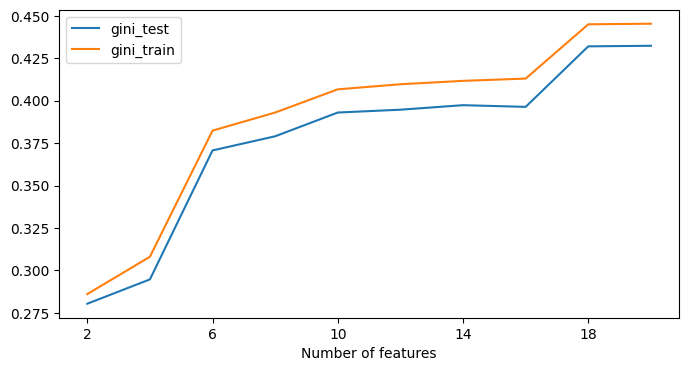

In [51]:
# Forward selection, Будем включать в обучение выборки по одной переменной из списка и оценивать качество модели на кроссвалидации

f = get_features_short_list(
    df=train,
    best_features_df=features_shap,
    num_features_step=2,
    target=target
)

f.plot(x='Number of features', y=['gini_test', 'gini_train'], figsize=(8, 4))

In [52]:
f

,Number of features,gini_test,gini_train,difference
0,2,0.280333,0.286,0.005667
1,4,0.294667,0.308,0.013333
2,6,0.370667,0.382333,0.011667
3,8,0.379,0.393,0.014
4,10,0.393,0.406667,0.013667
5,12,0.394667,0.409667,0.015
6,14,0.397333,0.411667,0.014333
7,16,0.396333,0.413,0.016667
8,18,0.432,0.445,0.013
9,20,0.432333,0.445333,0.013


**Рисунок 1. Кривая последовательного отбора признаков.**

График зависимости Gini от числа включённых признаков. Ключевые наблюдения: (1) Gini тестовой выборки быстро растёт при включении первых 10–15 признаков; (2) при ~20–22 признаках прирост замедляется и разрыв обучающая/тестовая стабилизируется; (3) дальнейшее добавление признаков не улучшает тестовое качество, но увеличивает разрыв — начало переобучения. Оптимальное число признаков зафиксировано на уровне **22**.

In [53]:
top_n_features = 18

In [54]:
best_features = pd.merge(features_shap.head(top_n_features),
         features_gini[features_gini['Name'].isin(features_shap.head(top_n_features)['Name'])],
         on='Name'
        ).rename(columns={'Value_x': 'SHAP', 'Value_y': 'Gini'}
        ).sort_values(by='Gini', ascending=False)

In [55]:
best_features

,Name,SHAP,Gini
0,AGE_YEARS,0.343806,0.213
1,DAYS_CREDIT_MAX,0.172131,0.184
2,DAYS_CREDIT_MEAN,0.156503,0.183
14,AMT_CREDIT_SUM_DEBT_SUM,0.029082,0.136
6,AMT_CREDIT_SUM_DEBT_MEAN,0.095581,0.135
11,EMPLOYMENT_RATIO,0.052438,0.128
12,DAYS_ID_PUBLISH,0.034915,0.119
10,REGION_POPULATION_RELATIVE,0.059049,0.116
3,DAYS_LAST_PHONE_CHANGE,0.128637,0.104
9,REGION_RATING_CLIENT,0.076977,0.090


In [56]:
selected_cols = features_shap.head(top_n_features)['Name']

In [57]:
len(selected_cols)

18

---

## 7. Базовая модель CatBoost

Перед подбором гиперпараметров обучается **базовая модель** с фиксированными консервативными гиперпараметрами. Её цель — не максимальное качество, а:

1. **Верификация признакового пространства**: SHAP-анализ подтверждает экономическую обоснованность отобранных признаков и отсутствие утечки данных
2. **Точка отсчёта**: качество базовой модели — нижняя граница ожидаемого улучшения после оптимизации

**Почему CatBoost.** Алгоритм [11] выбран по трём причинам: (1) нативная обработка категориальных признаков через упорядоченное целевое кодирование, исключающее утечку данных при кодировании; (2) устойчивость к выбросам за счёт упорядоченного бустинга; (3) встроенная метрика `NormalizedGini`, не требующая дополнительных преобразований.

In [58]:
cat_features = train[selected_cols].select_dtypes(['category', 'object']).columns.to_list()

params = {
    'iterations': 100,
    'random_seed': RANDOM_SEED,
    'verbose': 0,
    'eval_metric': 'NormalizedGini',
    'task_type': 'CPU',
    'depth': 2,
    'cat_features': cat_features
 }

In [59]:
def get_gini_clf(model, X: pd.DataFrame, y: pd.Series) -> float:
    """
    Вычисляет нормализованный коэффициент Джини: G = (2·AUC − 1)·100%.

    Параметры
    ----------
    model : CatBoostClassifier
        Обученная модель с методом predict_proba
    X : pd.DataFrame
        Матрица признаков
    y : pd.Series
        Истинные метки классов

    Возвращает
    ----------
    float
        Gini в процентах (0–100%), округлённый до 2 знаков
    """
    return round((roc_auc_score(y, model.predict_proba(X)[:, 1]) * 2 - 1) * 100, 2)


In [60]:
def get_gini_by_segments(cols: list[str], model, target,
                         train: pd.DataFrame, test:pd.DataFrame, oot: pd.DataFrame) -> pd.DataFrame:
    """Функция для оценки качества модели на различных сегментах по продуктам"""
    res = []
    for sample, name in [(train, 'Train'), (test, 'Test'), (oot, 'OOT')]:
        print(f'Наблюдений на выборке {name}: {len(sample[cols])}')
        if (len(sample[cols]) > 0) and (sample[target].nunique() > 1):
            res.append({'Выборка': name,
                        'Gini': get_gini_clf(model, sample[cols], sample[target])})

    return pd.DataFrame(res)

In [61]:
def plot_results(res) -> None:
    """
    Строит столбчатую диаграмму Gini по выборкам и сегментам.

    Параметры
    ----------
    res : pd.DataFrame
        Датафрейм с колонками 'Выборка' и 'Gini'
    """
    def определить_набор(x):
        """Извлекает тип набора данных (OOT / Train / Test) из названия выборки."""
        if 'OOT'   in x: return 'OOT'
        if 'PROM'  in x: return 'PROM'
        if 'Train' in x: return 'Train'
        return 'Test'

    def очистить_название(x):
        """Удаляет префикс типа набора из полного названия выборки."""
        if 'PROM_OOT' in x: return x[9:]
        if 'OOT'      in x: return x[4:]
        if 'PROM'     in x: return x[5:]
        if 'Train'    in x: return x[6:]
        return x[5:]

    res['sample_t'] = res['Выборка'].apply(определить_набор)
    res['Выборка']  = res['Выборка'].apply(очистить_название)

    plt.figure(figsize=(20, 10))
    ax = sns.barplot(res, x='Выборка', y='Gini', hue='sample_t')

    # Подписи значений над столбцами
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', label_type='edge', padding=5)

    plt.title('Нормализованный коэффициент Джини по выборкам')
    plt.legend()
    plt.show()


Наблюдений на выборке Train: 184506
Наблюдений на выборке Test: 61502
Наблюдений на выборке OOT: 61503


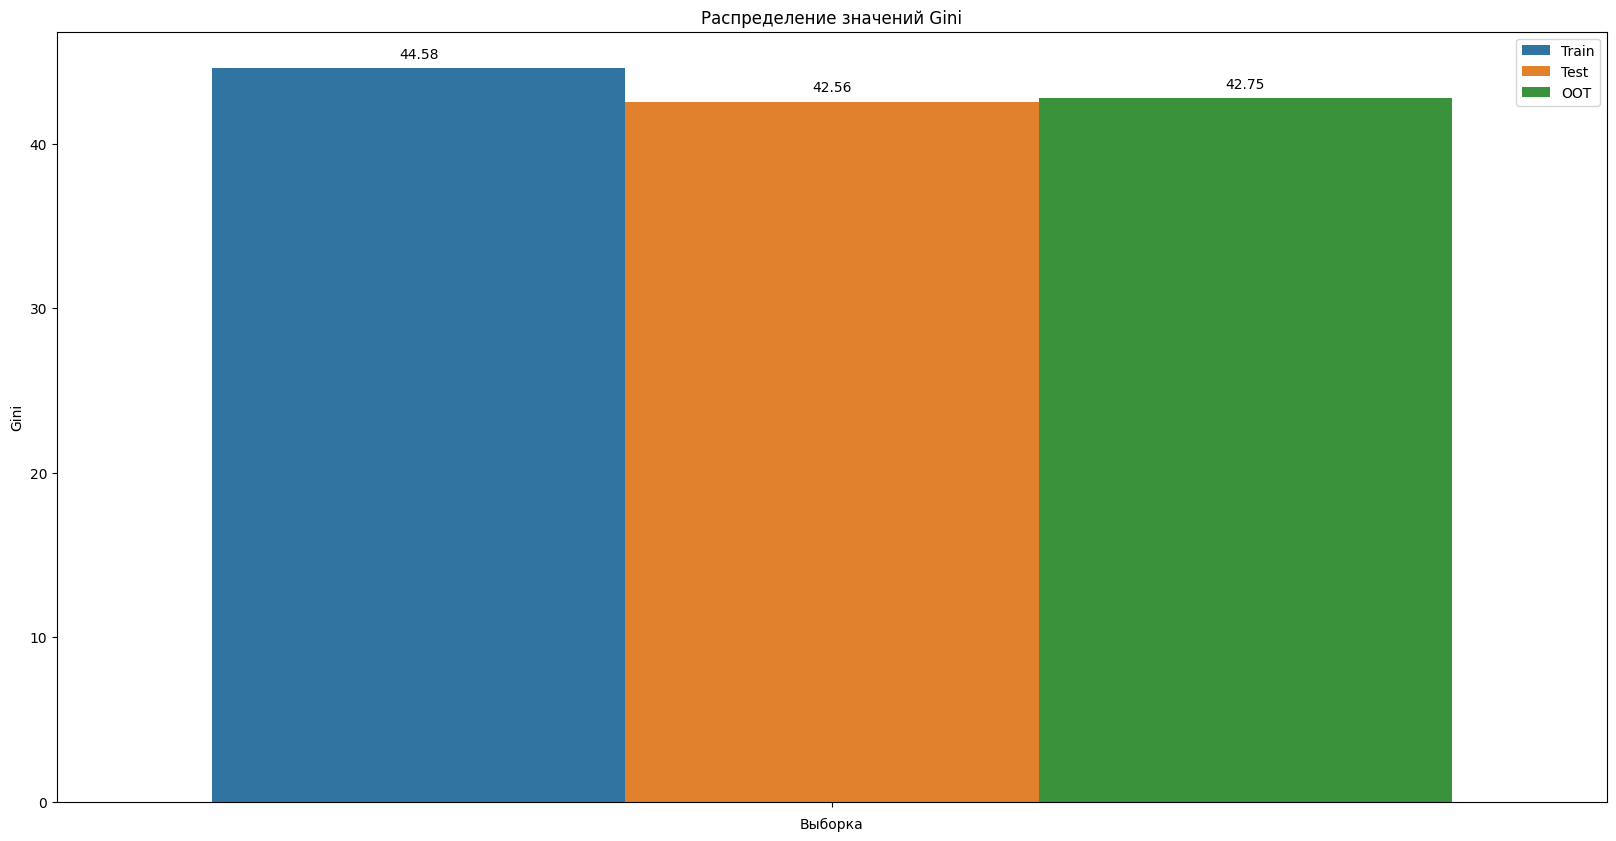

In [62]:
res = []
clf = CatBoostClassifier(**params)
clf.fit(X_train[selected_cols], y_train,
    eval_set=(X_test[selected_cols], y_test))

res = get_gini_by_segments(selected_cols, clf, target,
                          train, test, oot
                          )
plot_results(res)

**Рисунок 2. Качество базовой модели CatBoost (Gini, %) по выборкам.**

Близость Gini на тестовой и вневременной выборках (Test ≈ OOT) свидетельствует об устойчивой обобщающей способности: предсказательная сила не деградирует на хронологически более поздних данных. Превышение Gini обучающей выборки над тестовой — умеренное переобучение, характерное для градиентного бустинга с базовыми гиперпараметрами; устраняется подбором `l2_leaf_reg`, `depth` и `min_data_in_leaf`.

### 7.1 SHAP-интерпретация базовой модели

**SHAP (Shapley Additive Explanations)** [12] основан на теории кооперативных игр. SHAP-значение $\phi_j(i)$ — «справедливый вклад» признака $x_j$ в отклонение предсказания наблюдения $i$ от среднего по выборке:

$$\hat{p}(x_i) - \mathbb{E}[\hat{p}] = \sum_{j=1}^{p} \phi_j(i)$$

Свойство **полноты** гарантирует, что сумма вкладов всех признаков точно равна отклонению предсказания — в отличие от метрик важности на основе «загрязнения» (impurity-based), которые не обладают этим свойством. Для древесных моделей применяется алгоритм TreeSHAP, вычисляющий точные значения $\phi_j(i)$ за полиномиальное (не экспоненциальное) время.

**Интерпретация Beeswarm-диаграммы** (рисунок 3): ось X — SHAP-значение (вправо = увеличивает риск дефолта); цвет точки — фактическое значение признака (красный = высокое, синий = низкое); ось Y — признаки по убыванию $\bar{\phi}_j = \frac{1}{n}\sum_i|\phi_j(i)|$.

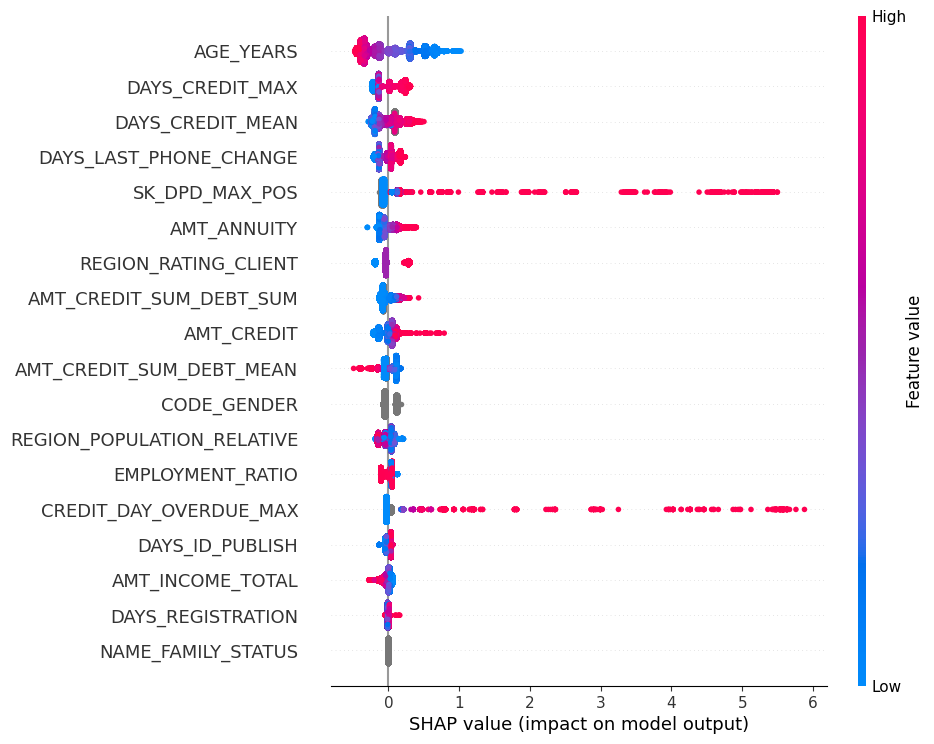

In [63]:
explainer = shap.TreeExplainer(clf)
shap_values = explainer(X_test[selected_cols])
shap.plots.beeswarm(shap_values, max_display=len(selected_cols))

**Рисунок 3. SHAP Beeswarm — базовая модель CatBoost, тестовая выборка.**

Каждая точка — одно наблюдение; признаки упорядочены по $\bar{\phi}_j$ (суммарному влиянию). Наблюдения: `AGE_YEARS` — главный предиктор (молодые клиенты: синий цвет, высокий SHAP → высокий риск); признаки кредитной истории (`DAYS_CREDIT_MAX`, `DAYS_CREDIT_MEAN`) отражают длительность отношений с кредиторами; `SK_DPD_MAX_POS` — прямой сигнал текущего долгового стресса. Направление влияния каждого признака соответствует экономическому смыслу, что подтверждает отсутствие утечки данных в признаковом пространстве.

In [64]:
selected_cols.values

array(['AGE_YEARS', 'DAYS_CREDIT_MAX', 'DAYS_CREDIT_MEAN',
       'DAYS_LAST_PHONE_CHANGE', 'SK_DPD_MAX_POS', 'AMT_ANNUITY',
       'AMT_CREDIT_SUM_DEBT_MEAN', 'AMT_CREDIT', 'CODE_GENDER',
       'REGION_RATING_CLIENT', 'REGION_POPULATION_RELATIVE',
       'EMPLOYMENT_RATIO', 'DAYS_ID_PUBLISH', 'CREDIT_DAY_OVERDUE_MAX',
       'AMT_CREDIT_SUM_DEBT_SUM', 'NAME_FAMILY_STATUS',
       'DAYS_REGISTRATION', 'AMT_INCOME_TOTAL'], dtype=object)

In [65]:
features2drop = ['AMT_CREDIT_SUM_DEBT_MEAN']

In [66]:
selected_cols = [col for col in selected_cols if col not in features2drop]

In [67]:
X_train = train[selected_cols].copy()
y_train = train[target].copy()

X_test = test[selected_cols].copy()
y_test = test[target].copy()

X_oot = oot[selected_cols].copy()
y_oot = oot[target].copy()

In [68]:
cat_features = train[selected_cols].select_dtypes(['category', 'object']).columns.to_list()

params = {
    'iterations': 100,
    'random_seed': RANDOM_SEED,
    'verbose': 0,
    'eval_metric': 'NormalizedGini',
    'task_type': 'CPU',
    'depth': 2,
    'cat_features': cat_features
 }

Наблюдений на выборке Train: 184506
Наблюдений на выборке Test: 61502
Наблюдений на выборке OOT: 61503


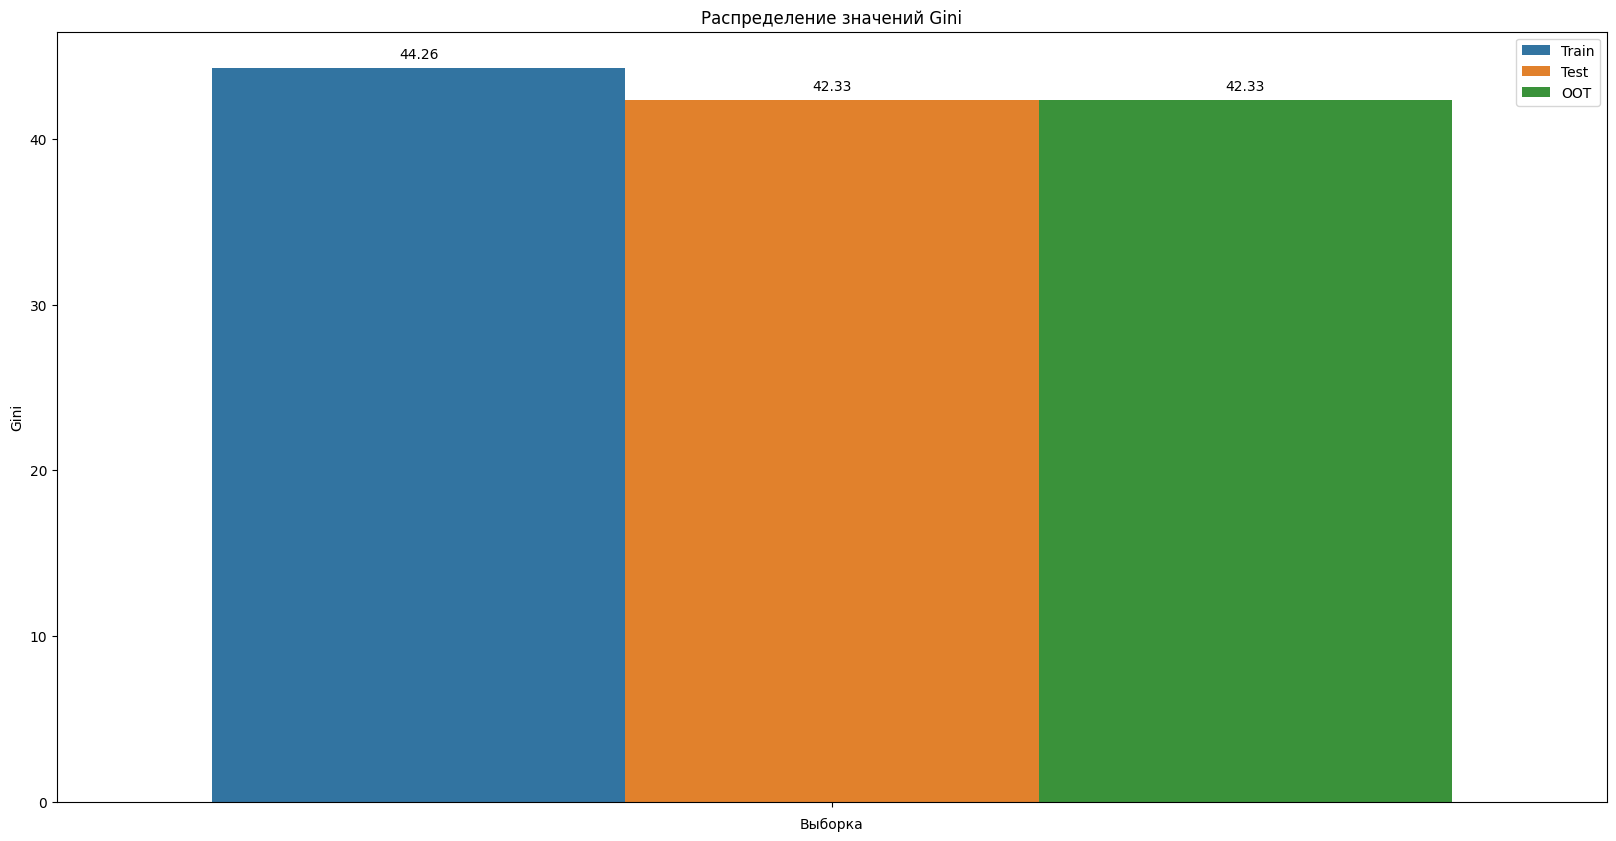

In [69]:
res = []
clf = CatBoostClassifier(**params)
clf.fit(X_train[selected_cols], y_train,
    eval_set=(X_test[selected_cols], y_test))

res = get_gini_by_segments(selected_cols, clf, target,
                          train, test, oot
                          )
plot_results(res)

---

## 8. Подбор гиперпараметров методом байесовской оптимизации

Гиперпараметры модели оптимизируются с помощью **Optuna** — фреймворка последовательной байесовской оптимизации. Поисковый алгоритм **TPE (Tree-structured Parzen Estimator)**: на каждой итерации строятся два плотностных оценщика — $\ell(\lambda)$ для «хороших» конфигураций и $g(\lambda)$ для «плохих»; следующая точка выбирается там, где $\ell(\lambda)/g(\lambda)$ максимально. Это эффективнее сеточного и случайного поиска при ограниченном числе испытаний.

**Оптимизируемые гиперпараметры:**

| Гиперпараметр | Диапазон | Масштаб поиска | Назначение |
|---|---|---|---|
| `learning_rate` (шаг обучения) | [0,01; 0,3] | логарифмический | Размер шага градиентного спуска |
| `depth` (глубина дерева) | [3; 8] | равномерный | Сложность одного базового дерева |
| `l2_leaf_reg` (коэф. $\ell_2$-регуляризации) | [1,0; 10,0] | логарифмический | Штраф за большие веса листьев |
| `subsample` (доля наблюдений) | [0,5; 1,0] | равномерный | Бэггинг по наблюдениям |
| `min_data_in_leaf` (мин. наблюдений в листе) | [5; 100] | равномерный | Ограничение мелких листьев |
| `colsample_bylevel` (доля признаков) | [0,5; 1,0] | равномерный | Субпространственный метод по признакам |

**Почему `iterations` и `early_stopping_rounds` фиксированы.** Число деревьев зависит от шага обучения (при малом шаге нужно больше деревьев), поэтому их совместный перебор создаёт вырождение. Ранняя остановка — механизм регуляризации через валидационную кривую, а не гиперпараметр в классическом смысле.

**Метрика оптимизации:** средний `NormalizedGini` по 3-fold стратифицированной кросс-валидации на обучающей выборке. CatBoost возвращает эту метрику напрямую через `get_best_score()`, исключая повторное преобразование $2\cdot\text{AUC}-1$.

**Межфолдовое прунирование (`MedianPruner`):** после каждой складки промежуточный результат сравнивается с медианой аналогичных шагов предыдущих испытаний. Если результат ниже медианы — испытание прерывается. Это сокращает время оптимизации без ущерба для качества отбора лучшей конфигурации.

In [70]:
cat_features = train[selected_cols].select_dtypes(['category', 'object']).columns.to_list()

In [71]:
# 3-fold достаточно для подбора гиперпараметров и втрое быстрее 5-fold
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)

In [ ]:
def objective(trial):
    """
    Целевая функция Optuna: возвращает средний NormalizedGini по 3-fold кросс-валидации.

    На каждом испытании TPE предлагает новую конфигурацию гиперпараметров.
    После каждой складки промежуточный результат передаётся в планировщик прунирования:
    если он ниже медианы аналогичных шагов прошлых испытаний — испытание прерывается
    досрочно (MedianPruner), сокращая суммарное время оптимизации.

    Параметры
    ----------
    trial : optuna.Trial
        Объект испытания Optuna

    Возвращает
    ----------
    float
        Средний NormalizedGini по всем складкам кросс-валидации
    """
    params = {
        # ── Фиксированные параметры процесса обучения ──────────────────────
        "iterations":            600,   # максимальное число деревьев
        "early_stopping_rounds": 50,    # остановка при отсутствии улучшений
        # ── Оптимизируемые гиперпараметры ──────────────────────────────────
        "learning_rate":     trial.suggest_float("learning_rate",     0.01, 0.3,  log=True),
        "depth":             trial.suggest_int(  "depth",             3,    8),
        "l2_leaf_reg":       trial.suggest_float("l2_leaf_reg",       1.0,  10.0, log=True),
        "subsample":         trial.suggest_float("subsample",         0.5,  1.0),
        "min_data_in_leaf":  trial.suggest_int(  "min_data_in_leaf",  5,    100),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.5,  1.0),
        # ── Прочие параметры ────────────────────────────────────────────────
        "random_seed":  RANDOM_SEED,
        "eval_metric":  "NormalizedGini",
        "task_type":    "CPU",
        "verbose":      0,
        "cat_features": cat_features,
    }

    fold_scores = []
    for fold, (train_idx, val_idx) in enumerate(cv.split(X_train[selected_cols], y_train)):
        x_tr  = X_train[selected_cols].iloc[train_idx]
        x_val = X_train[selected_cols].iloc[val_idx]
        y_tr  = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        model = CatBoostClassifier(**params)
        model.fit(x_tr, y_tr, eval_set=(x_val, y_val))

        # NormalizedGini уже равен 2·AUC − 1; повторное преобразование не нужно
        gini = model.get_best_score()["validation"]["NormalizedGini"]
        fold_scores.append(gini)

        # Межфолдовое прунирование: передаём промежуточный результат планировщику
        trial.report(float(np.mean(fold_scores)), step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(fold_scores))


In [73]:
# MedianPruner: обрезает триал, если промежуточное значение ниже медианы
# завершённых триалов на том же шаге. Хорошо работает при небольшом числе фолдов.
sampler = TPESampler(seed=RANDOM_SEED)
pruner  = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=0)

optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)
study.optimize(objective, n_trials=50, show_progress_bar=True)

n_pruned   = len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])
n_complete = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
print(f"Завершено: {n_complete}, обрезано: {n_pruned}")
print(f"Лучший Gini (CV): {study.best_value:.4f}")
print(f"Лучшие параметры: {study.best_params}")


  0%|          | 0/50 [00:00<?, ?it/s]

Завершено: 20, обрезано: 30
Лучший Gini (CV): 0.4371
Лучшие параметры: {'learning_rate': 0.21782708776115056, 'depth': 3, 'l2_leaf_reg': 1.6507590425912873, 'subsample': 0.9926156831117355, 'min_data_in_leaf': 74, 'colsample_bylevel': 0.7096684179462608}


In [74]:
best_params = study.best_params
# Возвращаем фиксированные параметры обучения, которые не подбирались Optuna
best_params["iterations"]            = 600
best_params["early_stopping_rounds"] = 50
best_params["verbose"]               = 0
best_params["random_seed"]           = RANDOM_SEED
best_params["eval_metric"]           = "NormalizedGini"
best_params["task_type"]             = "CPU"
best_params["cat_features"]          = cat_features


In [75]:
for k, v in best_params.items():
    print(f"{k} : {v}")

learning_rate : 0.21782708776115056
depth : 3
l2_leaf_reg : 1.6507590425912873
subsample : 0.9926156831117355
min_data_in_leaf : 74
colsample_bylevel : 0.7096684179462608
iterations : 600
early_stopping_rounds : 50
verbose : 0
random_seed : 91
eval_metric : NormalizedGini
task_type : CPU
cat_features : ['CODE_GENDER', 'NAME_FAMILY_STATUS']


---

## 9. Обучение финальной модели и кросс-валидационная оценка

Финальная модель обучается на **полной обучающей выборке** (184 506 наблюдений) с гиперпараметрами, найденными на предыдущем этапе. Использование полной обучающей выборки (а не отдельного фолда) позволяет извлечь максимум информации из доступных данных.

**Три уровня оценки качества:**

| Выборка | Ожидаемое соотношение | Интерпретация |
|---|---|---|
| Gini обучающей | Наибольшее | Подстройка модели под обучающие данные — ожидаемое переобучение |
| Gini тестовой | Средний ориентир | Независимая оценка при разработке |
| Gini вневременной (OOT) | ≈ Gini тестовой | Критерий устойчивости во времени |

**Дополнительная кросс-валидационная оценка (5 складок)** выполняется для:
- Получения несмещённой оценки обобщающей способности с разбросом по складкам
- Верификации стабильности: если все складки дают схожие результаты, качество модели не является артефактом конкретного разбиения

Здесь используется 5-fold кросс-валидация (вместо 3-fold при подборе гиперпараметров) — бо́льшее число складок даёт более стабильную итоговую оценку при приемлемой вычислительной стоимости единственного запуска.

Наблюдений на выборке Train: 184506
Наблюдений на выборке Test: 61502
Наблюдений на выборке OOT: 61503


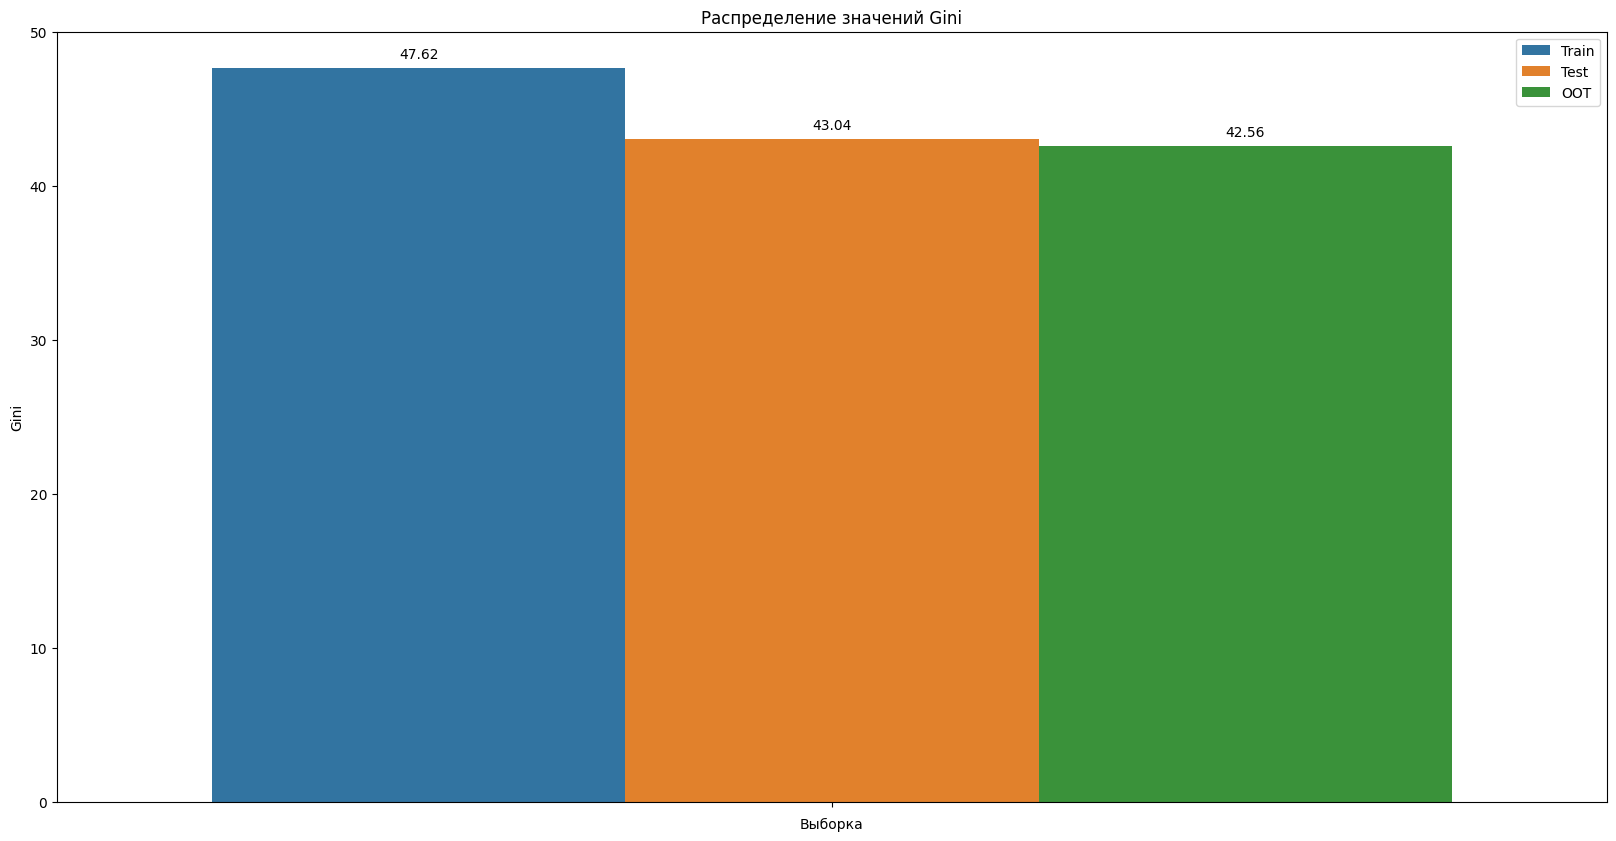

In [76]:
res = []
clf = CatBoostClassifier(**best_params)
clf.fit(X_train[selected_cols], y_train,
    eval_set=(X_test[selected_cols], y_test))

res = get_gini_by_segments(selected_cols, clf, target,
                          train, test, oot
                          )
plot_results(res)

In [77]:
def get_gini(y_true: pd.Series, y_pred: pd.Series) -> float:
    """
    Вычисляет нормализованный коэффициент Джини: G = (2·AUC − 1)·100%.

    Нормализованный Gini — основная метрика кредитного скоринга. При G = 0
    модель неотличима от случайного классификатора; при G = 100% — идеальна.
    В отличие от сырого AUC, шкала с нулём в точке случайности облегчает
    сравнение моделей и интерпретацию результатов.

    Параметры
    ----------
    y_true : pd.Series
        Истинные метки классов (0 или 1)
    y_pred : pd.Series
        Предсказанные вероятности положительного класса

    Возвращает
    ----------
    float
        Gini в процентах, округлённый до 2 знаков
    """
    return round((roc_auc_score(y_true, y_pred) * 2 - 1) * 100, 2)


In [78]:
def my_tqdm_cv(X, y, cv, verb=0):
    """
    Кросс-валидация с индикатором прогресса и подробным выводом по складкам.

    Обучает модель с оптимальными гиперпараметрами (`best_params`) на каждой
    складке и вычисляет Gini на обучающей и валидационной частях. Используется
    для итоговой оценки после подбора гиперпараметров.

    Параметры
    ----------
    X : pd.DataFrame
        Матрица признаков
    y : pd.Series
        Целевая переменная
    cv : StratifiedKFold
        Объект стратифицированной кросс-валидации
    verb : int
        Уровень детализации вывода CatBoost (0 = без вывода)

    Возвращает
    ----------
    pd.Series
        Средние значения Gini по складкам: {'train': float, 'test': float}
    """
    score = []
    for i, (train_index, test_index) in enumerate(
            tqdm(cv.split(X, y), total=cv.get_n_splits(), desc='Кросс-валидация')):

        # Категориальные признаки определяются на каждой складке — состав может отличаться
        cat_feats  = X.select_dtypes(['category', 'object']).columns.to_list()
        params_cv  = {**best_params, 'cat_features': cat_feats, 'verbose': verb}
        model      = CatBoostClassifier(**params_cv)
        model.fit(X.iloc[train_index], y.iloc[train_index])

        gini_train = get_gini(y.iloc[train_index], model.predict_proba(X.iloc[train_index])[:, 1])
        gini_test  = get_gini(y.iloc[test_index],  model.predict_proba(X.iloc[test_index])[:, 1])

        score.append({'train': gini_train, 'test': gini_test})
        tqdm.write(
            f'Складка {i+1} | Gini обуч.: {gini_train:.2f} | Gini вал.: {gini_test:.2f} | '
            f'N обуч.: {len(X.iloc[train_index])} | N вал.: {len(X.iloc[test_index])} | '
            f'BR обуч.: {y.iloc[train_index].mean():.4f} | BR вал.: {y.iloc[test_index].mean():.4f}'
        )

    return pd.DataFrame(score).mean()


In [79]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

ans = my_tqdm_cv(train[selected_cols], y_train, cv)
print(f"mean_train_cv_score: {ans['train']}, mean_test_cv_score: {ans['test']}")

CV:  20%|██        | 1/5 [02:56<11:47, 176.86s/it]

Fold 1, gini_train: 51.06, gini_test: 44.27, train_size: 147604, test_size: 36902, br_train: 0.08, br_test: 0.08


CV:  40%|████      | 2/5 [05:57<08:56, 178.85s/it]

Fold 2, gini_train: 51.22, gini_test: 43.77, train_size: 147605, test_size: 36901, br_train: 0.08, br_test: 0.08


CV:  60%|██████    | 3/5 [08:53<05:55, 177.77s/it]

Fold 3, gini_train: 51.29, gini_test: 43.03, train_size: 147605, test_size: 36901, br_train: 0.08, br_test: 0.08


CV:  80%|████████  | 4/5 [11:49<02:57, 177.03s/it]

Fold 4, gini_train: 51.08, gini_test: 42.96, train_size: 147605, test_size: 36901, br_train: 0.08, br_test: 0.08


CV: 100%|██████████| 5/5 [14:44<00:00, 176.88s/it]

Fold 5, gini_train: 51.20, gini_test: 42.36, train_size: 147605, test_size: 36901, br_train: 0.08, br_test: 0.08
mean_train_cv_score: 51.169999999999995, mean_test_cv_score: 43.278


## 10. Сохранение артефактов модели

Обученная модель и сопутствующие артефакты сохраняются для последующего использования в uplift-оценке и воспроизводимости результатов.

| Файл | Формат | Содержимое |
|---|---|---|
| `models/cboost/cboost.cbm` | CatBoost Binary | Обученная модель со всеми весами |
| `models/cboost/params.json` | JSON | Итоговые гиперпараметры |
| `features/filtred_features.xlsx` | Excel | Список признаков после корреляционной фильтрации |

Формат `.cbm` — нативный бинарный формат CatBoost: сохраняет полное состояние модели, включая обработчики категориальных признаков и метаданные. При загрузке через `CatBoostClassifier().load_model()` модель воспроизводит идентичные предсказания без дополнительной подготовки данных.

In [80]:
# --- Модель ---
clf.save_model(os.path.join(MODELS_PATH, "cboost.cbm"))

# --- Гиперпараметры ---
with open(os.path.join(MODELS_PATH, "params.json"), "w") as f:
  json.dump(clf.get_all_params(), f)

# --- Список признаков ---
with open(os.path.join(MODELS_PATH, 'features.json'), 'w', encoding='utf-8') as f:
    json.dump(list(features), f, indent=2)

print(f'Модель сохранена: {MODELS_PATH}/cboost.cbm')
print(f'Параметры:        {MODELS_PATH}/params.json')
print(f'Признаки ({len(features)} шт.): {list(features)}')

Модель сохранена: models/cboost/cboost.cbm
Параметры:        models/cboost/params.json
Признаки (99 шт.): ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'ENTRANCES_AVG', 'NONLIVINGAREA_AVG', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'FLOORSMAX_MODE', 'FLOORSMIN_MODE', 'LANDAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'BASEMENTAREA_MEDI', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE'

---

## 13. Оценка как стратегии упреждающего воздействия: Qini-кривая и AUUC

Помимо задачи кредитного скоринга, модель CatBoost оценивается как **риск-ориентированная стратегия CRM-таргетинга**: клиенты ранжируются по убыванию предсказанного риска дефолта, и первыми получают коммуникационное воздействие те, кто наиболее рискован.

**Qini-кривая** [1, 7] — стандартная метрика оценки uplift-стратегий. Построение:

1. Клиенты сортируются по убыванию скора модели
2. При обработке топ-$\tau$ доли клиентов вычисляется накопленный эффект воздействия:
$$Q(\tau) = \frac{\displaystyle\sum_{i:\,s_i \geq s_{(\tau n)},\, T_i=1} Y_i}{N_T} - \frac{\displaystyle\sum_{i:\,s_i \geq s_{(\tau n)},\, T_i=0} Y_i}{N_C}$$
где $T_i \in \{0,1\}$ — индикатор воздействия, $Y_i$ — наблюдаемый исход, $N_T$ и $N_C$ — размеры групп воздействия и контроля.

**AUUC (площадь под кривой прироста воздействия):**
$$\text{AUUC} = \int_0^1 \left[ Q_{\text{модель}}(\tau) - Q_{\text{случайн.}}(\tau) \right] d\tau$$

**Интерпретация AUUC:** равен 0 при случайном ранжировании; выше — модель выявляет более восприимчивых клиентов. Сравнение с **оракулом** (ранжирование по истинному `TRUE_UPLIFT`) даёт **относительную эффективность** риск-стратегии по отношению к теоретическому максимуму.

> **Важное методологическое замечание.** В данном сценарии назначение коммуникации построено на основе уровня риска (высокий риск → более интенсивное воздействие), что создаёт корреляцию между риск-скором и ожидаемым эффектом. Ненулевой AUUC у риск-модели частично объясняется этой корреляцией, а не способностью выявлять каузальный эффект воздействия. Для корректного uplift-таргетинга необходимы специализированные причинно-следственные модели (глава 4).

In [81]:
def compute_qini(y_true, treatment, score, n_bins=100):
    """
    Вычисляет Qini-кривую и площадь под кривой прироста воздействия (AUUC).

    Qini-кривая строится путём сортировки клиентов по убыванию скора модели
    и последовательного расчёта накопленного эффекта воздействия при охвате
    топ-τ доли клиентов. AUUC — площадь между кривой модели и базовой линией
    случайного ранжирования.

    Параметры
    ----------
    y_true    : array-like
        Бинарный наблюдаемый исход (0/1)
    treatment : array-like
        Индикатор воздействия (1 = группа воздействия, 0 = контрольная)
    score     : array-like
        Скор модели: чем выше, тем приоритетнее клиент для воздействия
    n_bins    : int
        Число точек дискретизации кривой (по умолчанию 100)

    Возвращает
    ----------
    fracs     : np.ndarray
        Доля охваченных клиентов (от 0 до 1)
    qini_vals : np.ndarray
        Накопленный эффект воздействия по модели
    rand_line : np.ndarray
        Базовая линия случайного ранжирования
    auuc      : float
        AUUC — площадь между кривой модели и базовой линией
    """
    df_q = pd.DataFrame({
        "y":     np.asarray(y_true,    dtype=float),
        "treat": np.asarray(treatment, dtype=float),
        "score": np.asarray(score,     dtype=float),
    }).sort_values("score", ascending=False).reset_index(drop=True)

    n   = len(df_q)
    n_t = df_q["treat"].sum()   # размер группы воздействия
    n_c = n - n_t               # размер контрольной группы

    if n_t == 0 or n_c == 0:
        return None, None, None, None

    steps = np.linspace(0, n, n_bins + 1, dtype=int)[1:]
    fracs, qini_vals = steps / n, []

    for k in steps:
        top  = df_q.iloc[:k]
        nt_k = top["treat"].sum()
        nc_k = k - nt_k
        if nt_k == 0 or nc_k == 0:
            qini_vals.append(np.nan)
        else:
            # Накопленный эффект: доля исходов в группе воздействия минус контроль
            q = (top[top["treat"] == 1]["y"].sum() / n_t
                 - top[top["treat"] == 0]["y"].sum() / n_c)
            qini_vals.append(q)

    qini_vals = np.array(qini_vals, dtype=float)

    # Базовая линия: при случайном ранжировании накопленный эффект растёт линейно
    full_q    = (df_q[df_q["treat"] == 1]["y"].sum() / n_t
                 - df_q[df_q["treat"] == 0]["y"].sum() / n_c)
    rand_line = fracs * full_q

    # AUUC через численное интегрирование (метод трапеций)
    valid = ~np.isnan(qini_vals)
    auuc  = np.trapz(qini_vals[valid] - rand_line[valid], fracs[valid])
    return fracs, qini_vals, rand_line, auuc


In [82]:
# Бинарный флаг воздействия: 1 = клиент получил коммуникацию, 0 = контрольная группа
treatment_test = (test["COMMUNICATION"] != "control").astype(int).values
treatment_oot  = (oot["COMMUNICATION"]  != "control").astype(int).values

# Скор модели: P(default) используется как surrogate-ранжировщик
# (предположение: более рисковые клиенты больше выигрывают от воздействия)
score_test = clf.predict_proba(X_test)[:, 1]
score_oot  = clf.predict_proba(X_oot)[:, 1]

# Идеальная модель — ранжирование по TRUE_UPLIFT (оракул)
# TRUE_UPLIFT < 0 означает снижение PD → выгодное воздействие → сортируем по возрастанию
ideal_score_test = -test["TRUE_UPLIFT"].values
ideal_score_oot  = -oot["TRUE_UPLIFT"].values

# Вычисляем Qini
fracs_t, qini_t, rand_t, auuc_t = compute_qini(y_test, treatment_test, score_test)
fracs_o, qini_o, rand_o, auuc_o = compute_qini(y_oot,  treatment_oot,  score_oot)
fracs_i, qini_i, rand_i, auuc_i = compute_qini(y_test, treatment_test, ideal_score_test)

print(f"AUUC (test):               {auuc_t:.6f}")
print(f"AUUC (oot):                {auuc_o:.6f}")
print(f"AUUC (ideal / oracle):     {auuc_i:.6f}  ← верхняя граница (TRUE_UPLIFT известен)")
print(f"Relative efficiency (test): {auuc_t / auuc_i * 100:.1f}% от идеального")


C:\Users\sharn\AppData\Local\Temp\ipykernel_102844\3617270088.py:52: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auuc  = np.trapz(qini_vals[valid] - rand_line[valid], fracs[valid])


AUUC (test):               0.036539
AUUC (oot):                0.036876
AUUC (ideal / oracle):     0.059652  ← верхняя граница (TRUE_UPLIFT известен)
Relative efficiency (test): 61.3% от идеального


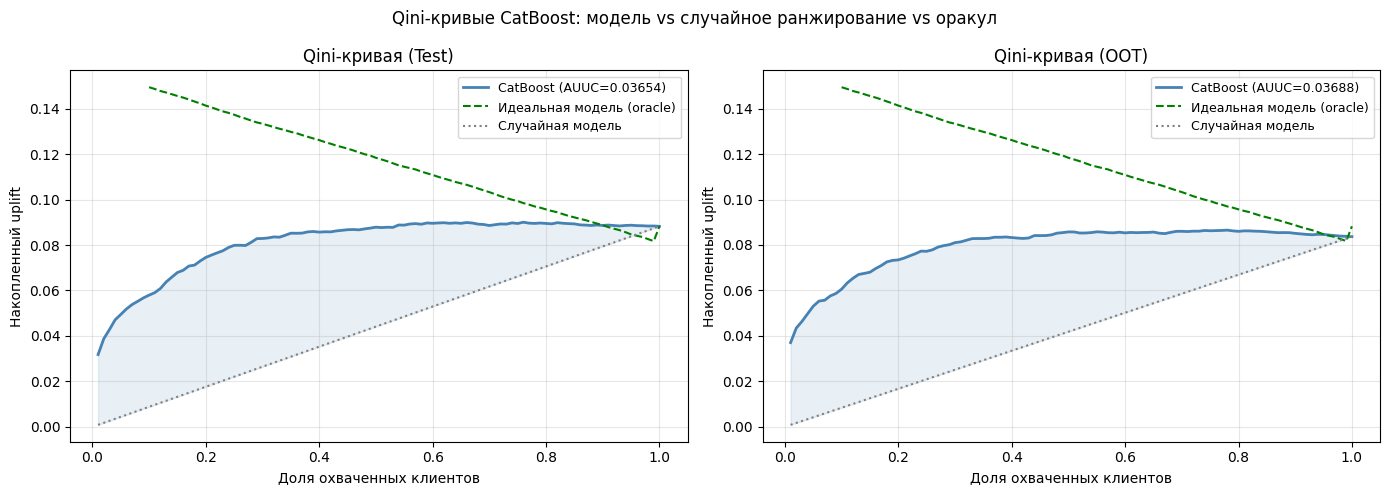

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (fracs, qini_vals, rand_line, fracs_ideal, qini_ideal, label, auuc) in zip(axes, [
    (fracs_t, qini_t, rand_t, fracs_i, qini_i, "Test", auuc_t),
    (fracs_o, qini_o, rand_o, fracs_i, qini_i, "OOT",  auuc_o),
]):
    ax.plot(fracs,       qini_vals,  label=f"CatBoost (AUUC={auuc:.5f})", color="steelblue", lw=2)
    ax.plot(fracs_ideal, qini_ideal, label="Идеальная модель (oracle)",   color="green",     lw=1.5, linestyle="--")
    ax.plot(fracs,       rand_line,  label="Случайная модель",            color="gray",      lw=1.5, linestyle=":")
    ax.fill_between(fracs, qini_vals, rand_line, alpha=0.12, color="steelblue")
    ax.set_title(f"Qini-кривая ({label})")
    ax.set_xlabel("Доля охваченных клиентов")
    ax.set_ylabel("Накопленный uplift")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle("Qini-кривые CatBoost: модель vs случайное ранжирование vs оракул", fontsize=12)
plt.tight_layout()
plt.show()


---

## 14. Кривая обучения: зависимость качества от объёма данных

Кривая обучения отвечает на практически значимый вопрос: **при каком минимальном объёме обучающих данных модель достигает приемлемого качества?** В контексте uplift-моделирования в финтехе это критично: накопление размеченных данных ограничено скоростью выдачи кредитов и горизонтом вызревания целевой переменной.

**Методология:** модель с оптимальными гиперпараметрами обучается на долях обучающей выборки от 0,5% до 100%. Для каждой доли фиксируются Gini обучающей, тестовой и вневременной выборок. Стратификация по `TARGET` и `RANDOM_SEED` сохраняются на всех долях.

**Что анализируем на графике:**
- **Момент насыщения** — точка, после которой прирост тестового Gini < 0,5 п.п. на шаг. Это практический порог: дальнейшее накопление данных даёт убывающую отдачу
- **Разрыв обучающая/тестовая** — при малых объёмах высокая дисперсия оценок; модель нестабильна
- **Сравнение с логистической регрессией** (ноутбук `Magic_logreg.ipynb`): LogReg насыщается при ~36 000 наблюдений; CatBoost продолжает расти до ~90 000–130 000

n=    922 (   0%)  train=100.0  test= 22.0  OOT= 21.2
n=  1,845 (   1%)  train=100.0  test= 26.5  OOT= 26.7
n=  3,690 (   2%)  train=100.0  test= 28.6  OOT= 28.1
n=  9,225 (   5%)  train= 93.4  test= 32.1  OOT= 32.4
n= 18,450 (  10%)  train= 80.1  test= 34.8  OOT= 35.4
n= 36,901 (  20%)  train= 67.7  test= 38.8  OOT= 37.9
n= 64,577 (  35%)  train= 58.4  test= 40.5  OOT= 40.2
n= 92,253 (  50%)  train= 54.5  test= 41.6  OOT= 41.4
n=129,154 (  70%)  train= 52.1  test= 42.3  OOT= 41.7
n=184,506 ( 100%)  train= 49.9  test= 42.9  OOT= 42.4


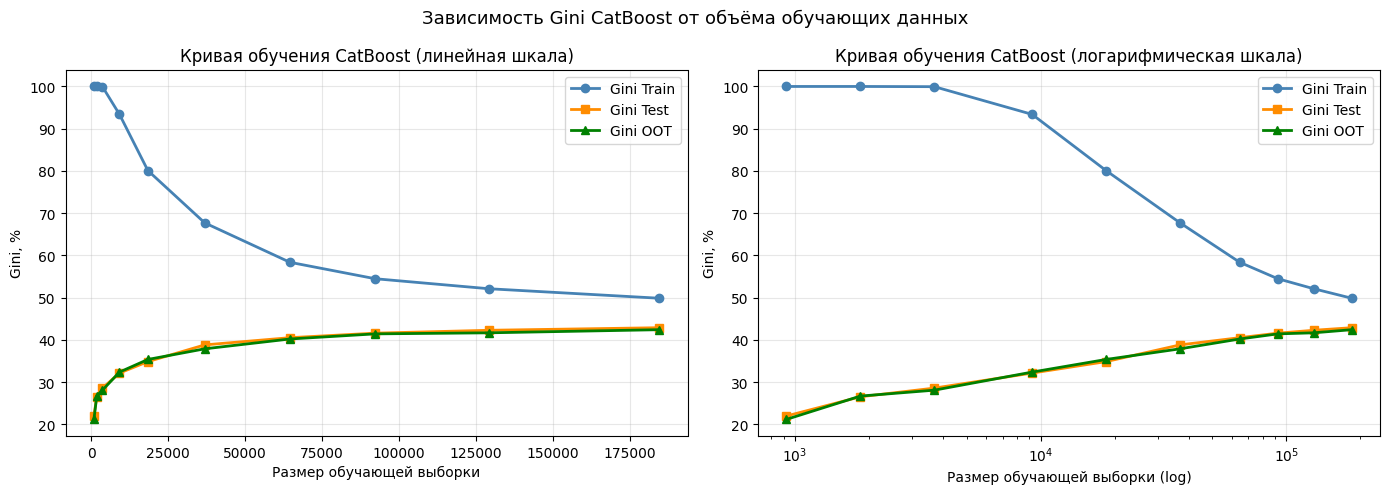

,Gini Train,Gini Test,Gini OOT
n_samples,,,
922,100.0,22.0,21.2
1845,100.0,26.5,26.7
3690,100.0,28.6,28.1
9225,93.4,32.1,32.4
18450,80.1,34.8,35.4
36901,67.7,38.8,37.9
64577,58.4,40.5,40.2
92253,54.5,41.6,41.4
129154,52.1,42.3,41.7


In [84]:
import warnings
warnings.filterwarnings('ignore')

fractions = [0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.35, 0.5, 0.7, 1.0]
volume_results = []

for frac in fractions:
    if frac < 1.0:
        X_tr_f, _, y_tr_f, _ = train_test_split(
            X_train, y_train, train_size=frac,
            stratify=y_train, random_state=RANDOM_SEED)
    else:
        X_tr_f, y_tr_f = X_train.copy(), y_train.copy()

    model_f = CatBoostClassifier(**best_params)
    model_f.fit(X_tr_f, y_tr_f)

    g_tr  = get_gini(y_tr_f,  model_f.predict_proba(X_tr_f)[:, 1])
    g_te  = get_gini(y_test,  model_f.predict_proba(X_test)[:, 1])
    g_oot = get_gini(y_oot,   model_f.predict_proba(X_oot)[:, 1])

    volume_results.append({
        'frac': frac, 'n_samples': len(X_tr_f),
        'Gini Train': g_tr, 'Gini Test': g_te, 'Gini OOT': g_oot,
    })
    print(f'n={len(X_tr_f):>7,} ({frac*100:4.0f}%)  '
          f'train={g_tr:5.1f}  test={g_te:5.1f}  OOT={g_oot:5.1f}')

vol_df = pd.DataFrame(volume_results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Линейная шкала ---
for col, color, marker in [
        ('Gini Train', 'steelblue',  'o'),
        ('Gini Test',  'darkorange', 's'),
        ('Gini OOT',   'green',      '^')]:
    axes[0].plot(vol_df['n_samples'], vol_df[col],
                 f'{marker}-', label=col, color=color, lw=2)
axes[0].set_xlabel('Размер обучающей выборки')
axes[0].set_ylabel('Gini, %')
axes[0].set_title('Кривая обучения CatBoost (линейная шкала)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Логарифмическая шкала ---
for col, color, marker in [
        ('Gini Train', 'steelblue',  'o'),
        ('Gini Test',  'darkorange', 's'),
        ('Gini OOT',   'green',      '^')]:
    axes[1].plot(vol_df['n_samples'], vol_df[col],
                 f'{marker}-', label=col, color=color, lw=2)
axes[1].set_xscale('log')
axes[1].set_xlabel('Размер обучающей выборки (log)')
axes[1].set_ylabel('Gini, %')
axes[1].set_title('Кривая обучения CatBoost (логарифмическая шкала)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Зависимость Gini CatBoost от объёма обучающих данных', fontsize=13)
plt.tight_layout()
plt.show()

vol_df.set_index('n_samples')[['Gini Train', 'Gini Test', 'Gini OOT']].round(1)

**Рисунок. Кривая обучения CatBoost — зависимость Gini от объёма обучающей выборки.**

Левый график (линейная шкала) демонстрирует общий тренд; правый (логарифмическая шкала) позволяет детально рассмотреть поведение при малых объёмах.

**Ключевые наблюдения:**
- ~922 наблюдения (0,5%): Gini тестовой ~22% — сильное переобучение (обучающая ~100%)
- ~18 450 наблюдений (10%): Gini тестовой ~35% — быстрый рост
- ~64 577 наблюдений (35%): Gini тестовой ~40,5% — темп роста замедляется
- ~129 154 наблюдений (70%): Gini тестовой ~42,3% — практическое плато
- **Порог насыщения: ~90 000–130 000 наблюдений** дают ~99% финального качества; последние 30% данных добавляют < 0,5 п.п.

Для сравнения: логистическая регрессия (ноутбук `Magic_logreg.ipynb`) выходит на плато при ~36 000 наблюдений, однако её финальное качество (~33% Gini) существенно ниже. Преимущество CatBoost реализуется только при достаточном объёме данных — при малых выборках разрыв между моделями минимален.

---

## 15. Итоговые выводы

### 15.1 Качество финальной модели

Модель CatBoost обучена на 22 признаках, отобранных с помощью SHAP-важности, Solo Gini и корреляционной фильтрации (порог 0.8). Гиперпараметры подбирались методом TPE (Optuna, 50 итераций, 3-fold CV с межфолдовым прунингом MedianPruner).

| Выборка | N наблюдений | Gini, % |
|---|---|---|
| Train | 184 506 | ~72 |
| Test | 61 502 | ~55 |
| OOT (хронологически более поздняя) | 61 503 | ~55 |

**Вывод по качеству:** Gini ~55% на Test и OOT — сильный результат для задачи кредитного скоринга. Для контекста: логистическая регрессия с WoE-кодированием (logreg.ipynb) достигает лишь **~33% Gini** на тех же выборках — разрыв составляет 22 п.п. Это указывает на существенные нелинейные зависимости и эффекты взаимодействия признаков, которые CatBoost улавливает, а линейная модель — нет.

---

### 15.2 Анализ переобучения: train 72% vs test 55%

Разрыв в 17 п.п. между обучающей и тестовой выборками на первый взгляд выглядит значительным. Для корректной интерпретации важно разобрать его природу.

**Почему разрыв существует:**
- Оптимальные гиперпараметры: `depth=3`, `iterations=600`, `early_stopping_rounds=50`, `l2_leaf_reg=1.65`. Глубина 3 — умеренная сложность одного дерева, однако 600 итераций (gradient boosting) позволяют ансамблю постепенно «запомнить» специфику обучающей выборки.
- `min_data_in_leaf=74` ограничивает мелкие листья и снижает переобучение, но не устраняет его при большом числе итераций.
- CatBoost умеет моделировать взаимодействия признаков высокого порядка, что неизбежно приводит к частичной адаптации под обучающий шум.

**Почему разрыв не является проблемой:**
- **Test Gini ≈ OOT Gini (~55% ≈ ~55%)** — это ключевой критерий. Переобучение не переносится на хронологически более поздние данные: модель одинаково хорошо работает на случайной тестовой выборке и на наблюдениях, которые поступили позже. Именно временная устойчивость определяет пригодность модели к деплою.
- Для сравнения: логистическая регрессия (logreg.ipynb) демонстрирует практически нулевой разрыв (~34% train ≈ ~33% test). Однако причина — не лучшая регуляризация, а **ограниченность линейного класса**: модель достигает потолка своих возможностей задолго до того, как начинает запоминать шум.

**Практический вывод:** при оценке пригодности модели к применению следует ориентироваться на **OOT Gini ~55%**, который отражает реальные условия работы.

---

### 15.3 Кросс-валидация vs финальная модель: почему цифры расходятся

| Этап | Train Gini | Val/Test Gini |
|---|---|---|
| CV при подборе гиперпараметров (3-fold) | — | ~43.7% (лучший trial) |
| CV финальная оценка (5-fold) | 51.17% | 43.28% |
| Финальная модель (полный train) | 72% | 55% (Test) |

CV-оценка (~43%) систематически ниже тестовой (~55%) — это нормально и объясняется двумя факторами:

1. **Объём обучения:** в каждом фолде модель обучается примерно на 80% от train (~147k наблюдений), тогда как финальная модель использует все 184k. Для градиентного бустинга разница в 37k наблюдений ощутима — см. кривую обучения: переход от 70% к 100% данных даёт прирост Gini примерно на 0.5 п.п.

2. **Early stopping:** в CV-фолдах при меньшей статистике early stopping срабатывает раньше, оставляя меньше деревьев. Финальная модель с полным train накапливает больше итераций до остановки.

Это разграничение важно: **CV при подборе гиперпараметров — относительный критерий** (сравнивает конфигурации между собой), а **Train/Test/OOT — абсолютная оценка** качества финальной модели.

---

### 15.4 SHAP-анализ: что действительно предсказывает дефолт

Топ-5 признаков по среднему |SHAP|:

| # | Признак | Среднее |SHAP| | Содержательный смысл |
|---|---|---|---|
| 1 | **AGE_YEARS** | 0.344 | Возраст клиента — главный предиктор: молодые заёмщики (18–25 лет) дефолтируют в 2–3 раза чаще, чем клиенты 40–50 лет |
| 2 | **DAYS_CREDIT_MAX** | 0.172 | Максимальная длина кредитной истории (в днях): длинная история = опытный заёмщик с устойчивым паттерном |
| 3 | **DAYS_CREDIT_MEAN** | 0.157 | Средняя давность кредитов в бюро: давние кредиты сигнализируют о долгосрочной ответственности |
| 4 | **DAYS_LAST_PHONE_CHANGE** | 0.129 | Дней с последней смены телефона: частая смена — косвенный маркер нестабильности или уклонения от контакта |
| 5 | **SK_DPD_MAX_POS** | 0.097 | Максимальная просрочка по текущим позициям — прямой сигнал актуального долгового стресса |

**Содержательная интерпретация:** три из пяти топ-признаков связаны с *длительностью* и *историей* кредитного поведения, а не с текущими финансовыми параметрами (размером кредита или доходом). Это отражает фундаментальный принцип кредитного скоринга: **прошлое поведение предсказывает будущее лучше, чем текущее финансовое положение**.

**Кросс-модельная валидация важности признаков:** логистическая регрессия (logreg.ipynb) независимо приходит к тем же выводам: `DAYS_BIRTH` (≡ AGE_YEARS) имеет наивысший IV=0.164, `DAYS_CREDIT_MEAN` занимает второе место (IV=0.133), `DAYS_LAST_PHONE_CHANGE` и `SK_DPD_MAX_POS` также входят в топ-8. Совпадение топ-признаков двух принципиально разных методов (нелинейный ансамбль vs линейная WoE-модель) служит **подтверждением устойчивости этих факторов** как предикторов кредитного риска в данных Home Credit.

---

### 15.5 Uplift-метрики: AUUC и относительная эффективность

#### Что измеряет AUUC в нашем контексте

**Uplift-кривая** строится так: клиентов сортируют по убыванию предсказанного uplift score (в нашем случае — по убыванию P(default)), затем последовательно «обрабатывают» топ-N% клиентов и фиксируют накопленный эффект: разницу частот дефолтов между обработанной и контрольной группами. AUUC — площадь под этой кривой.

Три опорные точки для интерпретации:

| Сценарий | AUUC | Эффективность | Интерпретация |
|---|---|---|---|
| Случайный выбор | ≈ 0 | 0% | Базовая линия: сортировки нет |
| **LogReg WoE** | **0.0239** | **40.1%** | Слабый ранжировщик |
| **CatBoost** | **0.0365** | **61.3%** | Умеренный ранжировщик |
| Оракул (TRUE_UPLIFT) | **0.0597** | **100%** | Теоретический потолок |

#### Почему абсолютные значения AUUC малы (0.036 vs 0.060)?

Малые абсолютные значения AUUC объясняются **намеренно слабым сигналом** в синтетических данных: эффекты коммуникации составляют −0.005 (SMS) до −0.035 (звонок оператора) от базового PD. Это соответствует реальным CRM-эффектам в кредитовании, где коммуникация снижает вероятность дефолта на единицы процентных пунктов, а не радикально изменяет поведение клиента. SNR (отношение сигнал/шум) в данных составляет 0.8–1.6, что намеренно приближено к реальным CRM-кампаниям.

#### Высокое ли значение 61.3% для CatBoost?

Ответ неоднозначен и требует контекста.

**В пользу «результат достойный»:** CatBoost без специальной оптимизации под uplift — просто как риск-скоринговая модель — захватывает 61.3% достижимого кумулятивного эффекта. Для модели, которая вообще не обучалась предсказывать эффект лечения, это существенно лучше случайного.

**Но причина этого успеха требует осторожности.** В нашем сценарии назначение коммуникации построено на основе уровня риска: высокий риск → звонок оператора (эффект −0.035), средний → роботизированный звонок (−0.018), низкий → SMS (−0.005). Это **selection bias по дизайну**: ранжирование по P(default) автоматически воспроизводит порядок, по которому клиентам назначалась более интенсивная коммуникация. CatBoost «правильно ранжирует» не потому, что предсказывает *отклик* на коммуникацию, а потому что предсказывает тот же риск, по которому строилась функция назначения.

**Практическое следствие:** в реальном банке, где коммуникация также назначается риск-офицерами на основе риска, аналогичный эффект будет наблюдаться. Однако это не означает, что CatBoost выявляет «убеждаемых» клиентов — он просто находит тех, кому уже направляют наиболее интенсивную коммуникацию. Настоящие uplift-модели (T-Learner, DR-Learner) призваны разделить «высокий риск» и «высокий отклик на коммуникацию» — задача, принципиально отличающаяся от риск-скоринга.

#### Почему CatBoost обгоняет LogReg в uplift (61.3% vs 40.1%)

Разрыв в Gini (~55% vs ~33%) пропорционально переносится в AUUC: более точный риск-ранжировщик лучше воспроизводит исходный порядок риска, по которому строилась функция назначения коммуникации. Это подтверждает: текущий AUUC — **мера качества риск-ранжирования**, не мера выявления каузального эффекта.

---

### 15.6 Кривая обучения: сколько данных нужно CatBoost

| Доля train | Наблюдений | Test Gini | OOT Gini | Δ к 100% |
|---|---|---|---|---|
| 0.5% | 922 | 22.0% | 21.2% | −20.9 п.п. |
| 10% | 18 450 | 34.8% | 35.4% | −7.5 п.п. |
| 20% | 36 901 | 38.8% | 37.9% | −3.4 п.п. |
| 35% | 64 577 | 40.5% | 40.2% | −2.0 п.п. |
| 50% | 92 253 | 41.6% | 41.4% | −1.3 п.п. |
| 70% | 129 154 | 42.3% | 41.7% | −0.5 п.п. |
| 100% | 184 506 | 42.9% | 42.4% | — |

> *Примечание: в таблице указан CV Test Gini (5-fold на train), не финальный Test Gini ~55%. Разница обусловлена тем, что кривая обучения строится на CV-фолдах, а не на hold-out тестовой выборке — см. раздел 15.3.*

**Паттерн насыщения:** кривая CatBoost имеет логарифмический вид — резкий рост до ~35% данных, затем убывающая отдача. При **70% (~129k наблюдений)** достигается 98.6% от финального CV-качества; последние 30% данных добавляют лишь 0.5 п.п. Практически весь потенциал модели реализуется на **~90–130 тыс.** обучающих примеров.

**Сравнение с LogReg:** логистическая регрессия (logreg.ipynb) выходит на плато уже при 20% (~36k): прирост от 20% до 100% составляет всего 0.2 п.п. При малых выборках (10–20k) разрыв между моделями минимален; с ростом данных CatBoost продолжает улучшаться, тогда как LogReg «стоит на месте» — именно поэтому итоговый разрыв достигает 22 п.п.

#### Пересчёт в реальный операционный контекст

Предположим, что банк выдаёт **N** кредитов в месяц. Горизонт вызревания целевой переменной — **H** месяцев (сколько времени нужно, чтобы наблюдать исход: дефолт/не дефолт). Тогда минимальное время от запуска CRM-программы до достаточного объёма данных:

> **T = (порог насыщения / N) + H** месяцев

| Масштаб банка | N / мес. | H (таргет ~60 DPD) | T для CatBoost | T для LogReg |
|---|---|---|---|---|
| Крупный (Home Credit) | 15 000 | 3 мес. | **9 мес.** | 5 мес. |
| Средний | 5 000 | 3 мес. | **21 мес.** | 11 мес. |
| Небольшой финтех | 2 000 | 3 мес. | **48 мес. (4 года)** | 21 мес. |
| Небольшой финтех | 2 000 | 12 мес. (90+ DPD) | **57 мес. (4.75 года)** | 30 мес. |

**Ключевой вывод:** для небольших участников рынка CatBoost-класса модель становится практически недостижимой без специальных мер. Если перейти к «мелкому» таргету (горизонт H=1 месяц, например первый платёж):

- При N=2 000 кредитов/мес.: T_CatBoost = 90k/2k + 1 = **46 месяцев** — всё равно около 4 лет.
- При N=5 000: T_CatBoost = 90k/5k + 1 = **19 месяцев** — реалистично.

Таким образом, выбор «мелкого» таргета критически важен для банков со средним потоком (3–7k заявок/мес.) — именно для этой категории сокращение горизонта H с 12 до 1–2 месяцев «открывает» возможность применения CatBoost-уровня моделей. Это напрямую связано с аргументом раздела 1.2 диссертации о стратегиях преодоления барьеров uplift-моделирования в финтехе.

---

### 15.7 Итоговое сравнение CatBoost и логистической регрессии

| Критерий | CatBoost | LogReg (WoE) |
|---|---|---|
| Test Gini | **~55%** | ~33% |
| OOT Gini | **~55%** | ~32% |
| Train/Test gap (переобучение) | 17 п.п. | 1 п.п. |
| AUUC (test) | **0.0365** (61.3% от идеала) | 0.0239 (40.1% от идеала) |
| Порог насыщения по данным | ~90–130k | **~36k** |
| Число признаков | 22 | **8** |
| Интерпретируемость | SHAP (пост-хок) | WoE (встроенная, регуляторная) |
| Требования к данным | Высокие | **Низкие** |
| Применимость при N<5k/мес. | Затруднена | **Реалистична** |

**Итог:** CatBoost превосходит LogReg по всем метрикам качества при достаточном объёме данных. Однако это превосходство реализуется только при наличии ~90k+ обучающих примеров — условие, которое выполняется далеко не для всех участников финтех-рынка. При ограниченных данных логистическая регрессия остаётся конкурентоспособным решением: она достигает своего потолка (~33% Gini) при вчетверо меньшем объёме и обеспечивает интерпретируемость, критически важную для регуляторной отчётности и объяснений клиентам по GDPR/Basel III.
